In [1]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)   

# PyPSA Costs

In [2]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)


costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [3]:
os.getcwd()
os.chdir("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive")
os.getcwd()

'C:\\Users\\Pulin\\Desktop\\Msc_Thesis_Greenlab_Skive'

# Weather Data

In [4]:
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')
# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)
# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)
# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()
# Display the first few rows to verify
#print(PV_data.head())

In [5]:
CF_solar = PV_data.mean(axis = 1) # average all the years

In [6]:
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()


In [7]:
CF_wind = OnshoreWind_Data.mean(axis = 1) # average of all years for the different datasets

## NG Prices

In [8]:
current_dir = os.getcwd()
gas_file = os.path.join(current_dir, 'GasDailyBalancingPrice.xlsx')

# units is in DKK/kWh
gas_price_pre_oct_2021 = pd.read_excel("GasSystemBalanceUntil20221001.xlsx")

In [9]:
# 1. Clean and Deduplicate as you did
gas_price_pre_oct_2021["GasDay"] = pd.to_datetime(gas_price_pre_oct_2021["GasDay"]).dt.tz_localize(None)
gas_price_pre_oct_2021.index = pd.DatetimeIndex(gas_price_pre_oct_2021["GasDay"])
gas_price_pre_oct_2021 = gas_price_pre_oct_2021.groupby(level=0).mean(numeric_only=True)

# 2. Add a "dummy" row to ensure the LAST day gets all 24 hours
# This adds one more day at the very end of your existing index
last_day = gas_price_pre_oct_2021.index.max()
next_day = last_day + pd.Timedelta(days=1)
gas_price_pre_oct_2021.loc[next_day] = None 

# 3. Apply the 6-hour offset for the Danish Gas Day
gas_price_pre_oct_2021.index = gas_price_pre_oct_2021.index + pd.Timedelta(hours=6)

# 4. Resample and Forward Fill
# This propagates the 06:00 price through all 24 hours of that gas day
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021.resample('h').ffill()

# 5. Drop the very last hour (which belongs to the dummy day's 06:00 start)
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021_hourly.iloc[:-1]

In [10]:
gas_price_data = pd.read_excel(gas_file)

# 1. Convert the 'GasDay' column to datetime and remove timezone offset
gas_price_data["GasDay"] = pd.to_datetime(gas_price_data["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data.index = pd.DatetimeIndex(gas_price_data["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
gas_price_hourly = gas_price_data.resample('h').ffill()

In [11]:
# EURO -> DKK exchange rate
EUR_DKK_exchangerate = (gas_price_hourly["ExchangeRateEUR_DKK"]/100)

In [12]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] = ((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchangerate)*1000)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]

GasDay
2022-10-01 00:00:00    164.176696
2022-10-01 01:00:00    164.176696
2022-10-01 02:00:00    164.176696
2022-10-01 03:00:00    164.176696
2022-10-01 04:00:00    164.176696
                          ...    
2025-12-26 20:00:00     30.641750
2025-12-26 21:00:00     30.641750
2025-12-26 22:00:00     30.641750
2025-12-26 23:00:00     30.641750
2025-12-27 00:00:00     29.731466
Freq: h, Name: MarginalPurchasePriceEUR_MWh, Length: 28393, dtype: float64

In [13]:
part1 = gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"][:"2022-09-30"]*(1000/7.45)  # DKK/kwh -> EUR/MWh
part2 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"] # EUR/MWh

NG_price = pd.concat([part1, part2], axis=1)

# keep='last' prioritizes data from 'part2' for the overlapping hours
NG_price = NG_price[~NG_price.index.duplicated(keep='last')].sort_index()

# 4. Fill any remaining tiny gaps (just in case)
NG_price = NG_price.resample('H').ffill()

# 1. Fill missing values in the EUR_MWh column with the DKK column values
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].fillna(NG_price["GasBuyingPriceDKK"])

# 2. Drop the original DKK column if you no longer need it
NG_price = NG_price.drop(columns=["GasBuyingPriceDKK"])

In [14]:
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].ffill() 

# Electrcity Prices

In [15]:
"full spot price data el DK1";
elspotprices = pd.read_excel("Elspotprices1999_onwards.xlsx", index_col=0, parse_dates=True) # EUR/MWh

In [16]:
"øre/kWh";
tariff_el_use = {
    "2021": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.123)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.09,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.92         # Net Tariff: Spidslast
    },
     "2022": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.116)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 4.51,         # Net Tariff: Lavlast
        "el_tariff_high": 8.32,        # Net Tariff: Højlast
        "el_tariff_peak": 12.15         # Net Tariff: Spidslast
    },
    "2023": {
        "el_transmission_tariff": 5.8,
        "el_system_tariff": 5.4,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.16)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.43,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.33         # Net Tariff: Spidslast
    },
    "2024": {
        "el_transmission_tariff": 7.4,
        "el_system_tariff": 5.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.24)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 0.85,         # Net Tariff: Lavlast
        "el_tariff_high": 2.54,        # Net Tariff: Højlast
        "el_tariff_peak": 5.08,         # Net Tariff: Spidslast
    }

}

In [17]:
import pandas as pd
import numpy as np

def build_electricity_grid_price_w_tariff(Elspotprices, tariff_dict, year):
    """
    Inputs:
        Elspotprices : pd.DataFrame (containing 'SpotPriceEUR')
        tariff_dict  : The multi-year dictionary (tariff_el_use)
        year         : int or str (e.g., 2021)
    """
    year_str = str(year)
    
    # --- 1. PREVENT TYPE ERROR: Select only the numeric column and filter year ---
    # We select only the 'SpotPriceEUR' column to avoid adding fees to string columns
    spot = Elspotprices.loc[Elspotprices.index.year == int(year_str), "SpotPriceEUR"]
    
    # Ensure it's numeric (handles any strange characters in the Excel)
    spot = pd.to_numeric(spot, errors='coerce').dropna()
    
    # --- 2. GET TARIFFS ---
    d = tariff_dict[year_str]
    DKK_to_EUR_MWh = 10 / 7.45  # Conversion: (øre/kWh * 10) / exchange_rate
    
    hours = spot.index
    is_winter = hours.month.isin([1, 2, 3, 10, 11, 12])
    is_weekday = hours.weekday < 5 
    
    # Define Hour Brackets
    is_low_hr  = hours.hour.isin(range(0, 6))   # 00:00 - 05:59
    is_peak_hr = hours.hour.isin(range(17, 21)) # 17:00 - 20:59
    is_day_hr  = hours.hour.isin(range(6, 24))  # 06:00 - 23:59

    # --- 3. APPLY NET TARIFF LOGIC (N1 MODEL 3.0) ---
    # Baseline is Low
    net_tariff = pd.Series(d["el_tariff_low"], index=hours)
    
    # Apply High (Højlast) to all hours between 06:00 and 00:00
    net_tariff.loc[is_day_hr] = d["el_tariff_high"]
    
    # Apply Peak (Spidslast) ONLY in Winter AND on Weekdays during Peak Hours
    net_tariff.loc[is_winter & is_weekday & is_peak_hr] = d["el_tariff_peak"]

    # --- 4. CALCULATE FINAL PRICES ---
    fixed_fees_ore = d["el_transmission_tariff"] + d["el_system_tariff"] + d["el_tax"]
    
    # Buy Price = Spot + (Fixed Tariffs + DSO Net Tariff) converted to EUR/MWh
    buy_price = spot + (fixed_fees_ore + net_tariff) * DKK_to_EUR_MWh
    
    # Sell Price = Spot minus production/balancing fees
    sell_price = -spot + (d["el_prod_tariff"] * DKK_to_EUR_MWh)

    return buy_price, sell_price

In [18]:
import_price21, export_price21 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2021")
import_price22, export_price22 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2022")
import_price23, export_price23 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2023")
import_price24, export_price24 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2024")

# Carbon Emissions Grid

In [19]:
import pandas as pd
import requests

# g/Kwh -> t/MWh

def get_danish_co2_data(start_date="2023-01-01", end_date="2023-12-31"):
    # The API uses a 'Where' filter for dates. 
    # We target DK1 (West Denmark/Skive area)
    url = "https://api.energidataservice.dk/dataset/CO2Emis"
    params = {
        'filter': '{"PriceArea":["DK1"]}',
        'start': start_date,
        'end': end_date,
        'columns': 'Minutes5UTC,CO2Emission',
        'sort': 'Minutes5UTC ASC'
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    # Convert to DataFrame
    df = pd.DataFrame(data['records'])
    
    # Convert time to datetime objects and set as index
    df['Minutes5UTC'] = pd.to_datetime(df['Minutes5UTC'])
    df.set_index('Minutes5UTC', inplace=True)
    
    # The API provides 5-min data. Resample to HOURLY to match PyPSA
    # 'mean()' is used to get the average emission for that hour
    df_hourly = df['CO2Emission'].resample('h').mean()
    
    return df_hourly

# Example: Get data for your n23 year
co2_21_24 = get_danish_co2_data("2021-01-01", "2025-01-01")
print(co2_21_24.head())

# To add it to your PyPSA network:
# n23.generators_t.weight_carbon = co2_2023.values

Minutes5UTC
2020-12-31 23:00:00    190.833333
2021-01-01 00:00:00    196.000000
2021-01-01 01:00:00    168.166667
2021-01-01 02:00:00    160.083333
2021-01-01 03:00:00    161.083333
Freq: h, Name: CO2Emission, dtype: float64


In [20]:
grid_emissions = co2_21_24/1e3 # t/MWh

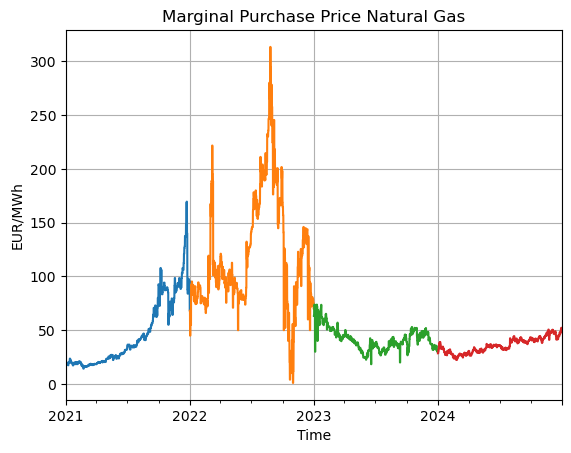

In [21]:
NG_price["MarginalPurchasePriceEUR_MWh"]["2021"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2022"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2023"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2024"].plot()
#elspotprices["SpotPriceEUR"].plot()
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.xlim("2021-01-01", "2024-12-31")
plt.title("Marginal Purchase Price Natural Gas")
plt.grid()

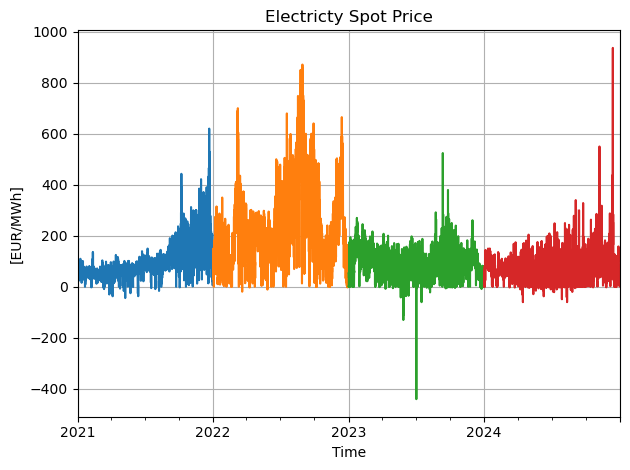

In [22]:
elspotprices["SpotPriceEUR"]["2021"].plot()
elspotprices["SpotPriceEUR"]["2022"].plot()
elspotprices["SpotPriceEUR"]["2023"].plot()
elspotprices["SpotPriceEUR"]["2024"].plot()
plt.ylabel("[EUR/MWh]")
plt.xlabel("Time")
plt.grid()
plt.title("Electricty Spot Price")
#plt.legend(["2021", "2022", "2023", "2024"])
plt.tight_layout()
plt.show()

In [94]:
"Filling Missing Data Values";

grid_emissions["2021":"2024"] = grid_emissions["2021":"2024"].ffill().bfill()

In [95]:
grid_emissions["2021":"2024"].isna().sum()

0

Text(0, 0.5, 't_Co2/MWh')

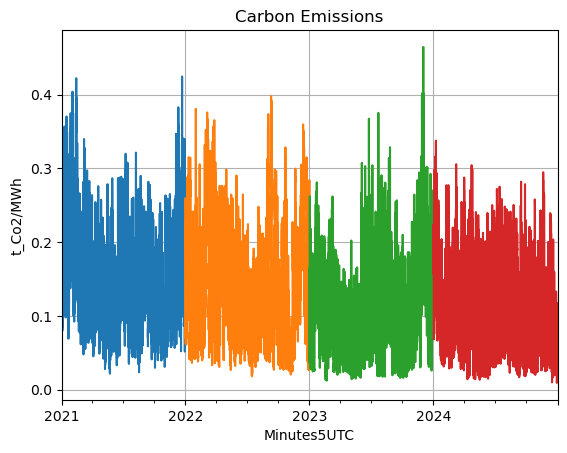

In [96]:
grid_emissions["2021"].plot()
grid_emissions["2022"].plot()
grid_emissions["2023"].plot()
grid_emissions["2024"].plot()
plt.title("Carbon Emissions")
plt.grid()
plt.ylabel("t_Co2/MWh")

In [24]:
def add_carriers(n):
    
    n.add("Carrier", "onshorewind")
    n.add("Carrier", "solar")

    n.add("Carrier", "imports")
    n.add("Carrier", "exports")

    n.add("Carrier", "battery_storage")
    #n.add("Carrier", "battery charging")
    #n.add("Carrier", "battery dicharging")

    n.add("Carrier","gas") 
    n.add("Carrier", "NG_boiler")

    n.add("Carrier", "pellets")

    n.add("Carrier","Pyrolysis")
    n.add("Carrier", "Biogas_plant")

    n.add("Carrier", "El_Boiler")
    
    n.add("Carrier", "RONDO_store")
    n.add("Carrier", "RONDO_charge")
    n.add("Carrier", "RONDO_discharge")

    n.add("Carrier", "biochar")
    n.add("Carrier", "biomass", unit = "t/h")
    n.add("Carrier", "CO2", unit = "t/h") 
    n.add("Carrier", "biochar_sequestered")


    n.add("Carrier", "methanol")
    n.add("Carrier", "Methanolisation")

    n.add("Carrier", "methane")

    n.add("Carrier", "heat")
    n.add("Carrier", "electricity")

In [25]:
def add_skive_generators(n,s_cf,w_cf):

    # EuroWind Owns These Assets
    n.add("Generator", "Skive_Solar", carrier="solar",
        bus = "Greenlab" , # Greenlab , EuroWind
        capital_cost=costs.at["solar", "capital_cost"],
        #marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu= s_cf, 
        p_nom = 30)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "Greenlab",
        capital_cost=costs.at["onwind", "capital_cost"],
        #marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu= w_cf,
        p_nom = 54)

In [270]:
def add_grid(n, price_import, price_export, grid_emissions, CO2tax):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
          bus="Grid_Import",
          p_nom_extendable=False,
          p_nom = 84, # GCP limit
          efficiency=1.0,
          marginal_cost=0,
          capital_cost=0.0,
          carrier="imports")

    n.add("Link", "Imports",
          bus0="Grid_Import",
          bus1="Greenlab",   # [EuroWind or Greenlab]
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="imports",
          marginal_cost=price_import + grid_emissions*CO2tax)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          #e_nom = 130e3, # MWh 
          e_0 = 0,
          capital_cost=0.0,
          standing_loss=0.0,
          carrier="exports")

    n.add("Link", "Exports",
          bus0="Greenlab",   # [EuroWind or Greenlab]
          bus1="Grid_Export",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="exports",
          marginal_cost=price_export)

In [27]:
def add_battery(n,P_nom, max_t, cyclic_operation = True):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="Greenlab",  # Use your electricity bus name {EuroWind, Greenlab}
        carrier="battery_storage",
        max_hours= max_t,  # 22 MW * 2 h = 44 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"] + 4 * costs.at["battery storage", "capital_cost"],
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # Discharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_extendable=False,
        cyclic_state_of_charge=cyclic_operation)

In [ ]:
"High Temprature Bus (350)";
def add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        #e_nom= e_nom_store, # MWh
        e_nom_extendable=True,
        e_nom_min = e_nom_store,
        e_nom_max = e_nom_store,
        e_cyclic=False,
        standing_loss= 1.2/100, # 1.2% per hour
        carrier = "RONDO_store",
        capital_cost=costs.at["Concrete-store", "capital_cost"] )      

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link",
        "El_to_TES_Rondo",
        bus0="Greenlab",
        bus1="TES_Rondo",
        p_nom_extendable=True,
        p_nom_min = p_nom_charge,
        p_nom_max = p_nom_charge, 
        # p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "RONDO_charge",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link",
        "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_MT",
        #p_nom = p_nom_discharge,
        p_nom_extendable=True,
        p_nom_min = p_nom_discharge,
        p_nom_max = p_nom_discharge,
        efficiency=0.90*0.8, # Including Efficency of Heat Exchanger here
        carrier = "RONDO_discharge",
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])

In [29]:
"Medium Temprature (150 C)";
def  add_electric_boiler(n):
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "Greenlab",
        bus1="Heat_MT",
        #p_nom = 10, # MW,
        p_nom_extendable = True,
        p_nom_min = 10,
        p_nom_max = 10,
        efficiency=0.9,
        carrier = "El_Boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"],
        #marginal_cost = costs.at["electric boiler steam","marginal_cost"]
        )

In [30]:
def add_NG_boiler(n,CO2tax, NG_price):
     n.add("Generator",
        "NG grid",
        bus="NG",
        carrier="gas",
        p_nom = 6,
        marginal_cost = NG_price + 0.202*CO2tax + 1.007, #0.206  tCO2/MWh *  80EUR/tC02 + VOM 1.007EUR/MWh
        p_nom_extendable=False,)

     n.add("Link","NG boiler",
        bus0="NG",
        bus1="Heat_MT",
        carrier = "NG_boiler",
        capital_cost = costs.at["decentral gas boiler","capital_cost"],
        efficiency=0.98,
        p_nom=6,
        p_nom_extendable=False,) 

- {P_heat = 5, P_el = 2} - constant
- Hence the total avialable pelletes we have for pyrolysis is,
- (0.02 MW_el/2.09 t/h Biomass) 
- (0.12 MW pellets / 2.09 t/h Biomass)

In [321]:
 (0.12*100)*len(n21.snapshots) # MWh

105048.0

In [452]:
def add_SkyClean_simple(n,CO2tax):  
    #n.add("Generator",
     #   "pellets input",
      #  bus="pellets",
       # carrier="pellets",
       # p_nom_extendable=True,
        #marginal_cost= 62) #€/MWh (Price of straw pellets 380 €/t
        #)

    n.add("Store",
    "pellets store",
     e_initial = (0.12*100)*len(n.snapshots), # MW (avialable pellets from a biogas plant) 
     e_nom = (0.12*100)*len(n.snapshots),
     bus = "pellets",
     carrier = "pellets",
     e_nom_extendable = False,
     e_cylic = False)
    
    # straw pellets cost from 35 - 82 EUR/ton
    # LHV_pellets = 16 MJ/kg
    

    n.add("Link",
        "pyrolysis",
        bus0="pellets",
        bus1="Heat_MT",
        bus2="biochar",
        bus3 = "Greenlab",
        p_nom_extendable=False,
        p_nom=2,
        efficiency = 8.5/20, # MW , 8.2/21.7 , Heat High Temp
        efficiency2 = 9/20, # MW , 10.1/21.7 , Biochar
        efficiency3 = -0.02, # MW, auxillary power (2 %)
        carrier="Pyrolysis",
        capital_cost=costs.at["biochar pyrolysis","capital_cost"],
        marginal_cost = 62, # EUR/MWh
        ) 

    
    n.add("Link",
        "biochar sequestration",
        bus0="biochar",
        bus1="biochar sequestration",
        efficiency=1,
        #p_nom = 1, # MW  
        p_nom_extendable = True,
        marginal_cost= -0.313*CO2tax,   #CO2 tax   or -0.164 (tCO2/MWh_pell)?  # -1  * co2_credits #-13.12eur/MWh
        carrier="biochar") 

    n.add(
        "Store",
        "biochar sequestred",
        bus="biochar sequestration",
        #e_nom = 8e3,
        e_nom_extendable=True,
        e_cyclic=False,
        carrier="biochar_sequestered")

In [344]:
def heat_load(n,P_heat = 5):
    n.add("Load", "Biogas_Heat", carrier = "heat",
        bus = "Heat_MT",
        p_set = P_heat)

def el_load(n,P_el = 2):
    n.add("Load", "Biogas_el", carrier = "electricity",
        bus = "Greenlab",
        p_set = P_el)

### Scenario 1

- simple biogasplant (fixed loads)
- no electrolyser + methanolisation

In [453]:
def build_network_simple(P_heat,P_el ,CO2_tax, grid_emissions,p_import, p_export, NG_price, horizon, overlap):
    n = pypsa.Network()
    # Set snapshots based on the Natural Gas price index
    n.set_snapshots(NG_price.index)

    
    # Align time-series data to snapshots
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_import = p_import.loc[n.snapshots].values
    p_export = p_export.loc[n.snapshots].values

    # grid_emissions = grid_emissions.loc[n.snapshots].values
    grid_emissions = grid_emissions.reindex(n.snapshots).ffill().values
    
    add_carriers(n)


    n.add("Bus", "Greenlab", carrier = "electricity")
    add_skive_generators(n,s_cf,w_cf)
    add_battery(n,P_nom = 22, max_t= 2, cyclic_operation = True)



    n.add("Bus", "Grid_Import", carrier  = "imports")
    n.add("Bus", "Grid_Export", carrier = "exports")
    add_grid(n, price_import = p_import, price_export = p_export, grid_emissions = grid_emissions, CO2tax = CO2_tax)


    n.add("Bus", "Heat_MT", carrier = "heat")
    add_electric_boiler(n)


    n.add("Bus", "TES_Rondo", carrier = "RONDO_store")
    add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7)


    n.add("Bus", "pellets", carrier = "pellets")
    n.add("Bus","biochar", carrier = "biochar")
    n.add("Bus", "biochar sequestration", carrier = "biochar_sequestered" )
    add_SkyClean_simple(n,CO2tax = CO2_tax)


    n.add("Bus", "NG", carrier = "gas")
    add_NG_boiler(n,CO2tax = CO2_tax, NG_price = NG_price)

    heat_load(n,P_heat = P_heat)
    el_load(n,P_el = P_el)


    # --- Solving Section ---
    if horizon is not None:
        # Rolling Horizon Optimization
        n.optimize.optimize_with_rolling_horizon(
            assign_all_duals = True,
            solver_name="gurobi", 
            horizon=horizon, overlap = overlap)
    else:
        # Full Year Optimization
        n.optimize(assign_all_duals = True,
            solver_name="gurobi",)

    return n

In [ ]:
n21 = build_network_simple(P_heat = 5,P_el = 2 ,CO2_tax = 80, grid_emissions = grid_emissions["2021"],p_import = import_price21, p_export = export_price21, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2021"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 12.08it/s]
INFO:linopy.io: Writing time: 5.03s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

Barrier performed 7 iterations in 1.26 seconds (0.66 work units)


INFO:gurobipy:Barrier performed 7 iterations in 1.26 seconds (0.66 work units)


Barrier solve interrupted - model solved by another algorithm


INFO:gurobipy:Barrier solve interrupted - model solved by another algorithm


INFO:gurobipy:


In [ ]:
n22 = build_network_simple(P_heat = 5,P_el = 2 ,CO2_tax = 80, grid_emissions = grid_emissions["2022"],p_import = import_price22, p_export = export_price22, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2022"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 13.66it/s]
INFO:linopy.io: Writing time: 4.37s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 29138 iterations and 5.54 seconds (0.92 work units)


INFO:gurobipy:Solved in 29138 iterations and 5.54 seconds (0.92 work units)


Optimal objective -2.075426560e+07


INFO:gurobipy:Optimal objective -2.075426560e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 201487 primals, 455531 duals
Objective: -2.08e+07
Solver model: available
Solver message: 2



In [ ]:
n23 = build_network_simple(P_heat = 5,P_el = 2 ,CO2_tax = 80, grid_emissions = grid_emissions["2023"],p_import = import_price23, p_export = export_price23, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2023"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 11.79it/s]
INFO:linopy.io: Writing time: 4.84s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 29568 iterations and 5.49 seconds (0.94 work units)


INFO:gurobipy:Solved in 29568 iterations and 5.49 seconds (0.94 work units)


Optimal objective -8.106736237e+06


INFO:gurobipy:Optimal objective -8.106736237e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 201487 primals, 455531 duals
Objective: -8.11e+06
Solver model: available
Solver message: 2



In [ ]:
n24 = build_network_simple(P_heat = 5,P_el = 2 ,CO2_tax = 80, grid_emissions = grid_emissions["2024"],p_import = import_price24, p_export = export_price24, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2024"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 13.21it/s]
INFO:linopy.io: Writing time: 4.67s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 32114 iterations and 5.51 seconds (0.95 work units)


INFO:gurobipy:Solved in 32114 iterations and 5.51 seconds (0.95 work units)


Optimal objective -6.211261383e+06


INFO:gurobipy:Optimal objective -6.211261383e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 202039 primals, 456779 duals
Objective: -6.21e+06
Solver model: available
Solver message: 2



<Axes: xlabel='snapshot'>

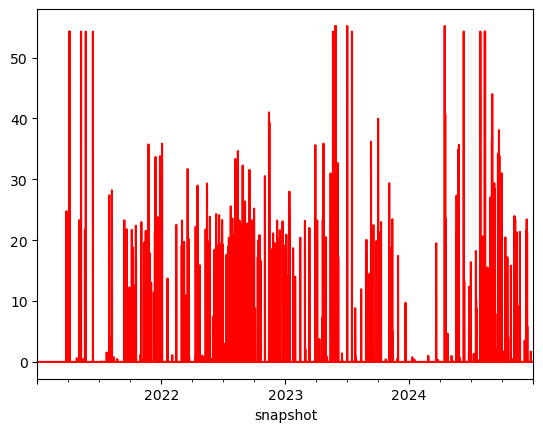

In [384]:
n21.links_t.p0["Imports"].plot(color = "red")
n22.links_t.p0["Imports"].plot(color = "red")
n23.links_t.p0["Imports"].plot(color = "red")
n24.links_t.p0["Imports"].plot(color = "red")

<Axes: xlabel='snapshot'>

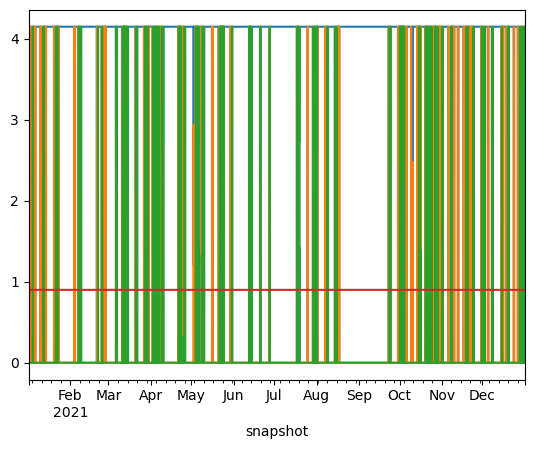

In [385]:
(-n21.links_t.p1["NG boiler"]).plot()
(-n21.links_t.p1["Boiler_Skive"]).plot()
(-n21.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"]).plot()
(-n21.links_t.p2["pyrolysis"]).plot()

<Axes: xlabel='snapshot'>

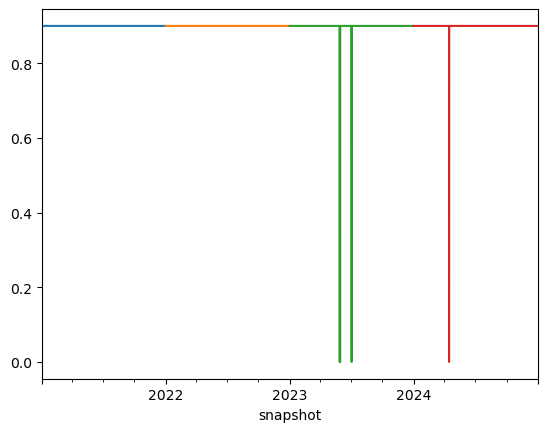

In [386]:
(-n21.links_t.p2["pyrolysis"]).plot()
(-n22.links_t.p2["pyrolysis"]).plot()
(-n23.links_t.p2["pyrolysis"]).plot()
(-n24.links_t.p2["pyrolysis"]).plot()

<Axes: xlabel='snapshot'>

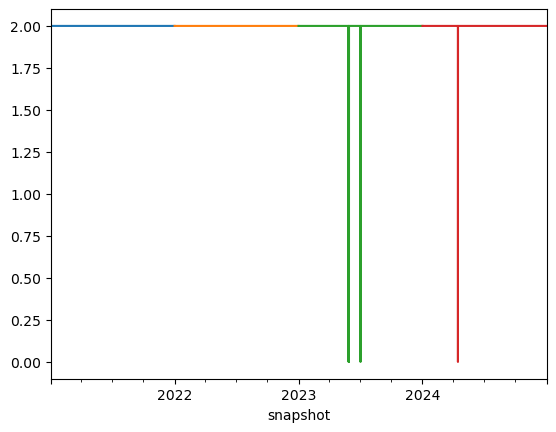

In [387]:
n21.links_t.p0["pyrolysis"].plot()
n22.links_t.p0["pyrolysis"].plot()
n23.links_t.p0["pyrolysis"].plot()
n24.links_t.p0["pyrolysis"].plot()

In [446]:
n21.stores_t.e["pellets store"][0] - n21.stores_t.p["pellets store"][-1], n22.stores_t.e["pellets store"][0] - n22.stores_t.p["pellets store"][-1]

(105044.0, 105116.0)

<Axes: xlabel='snapshot'>

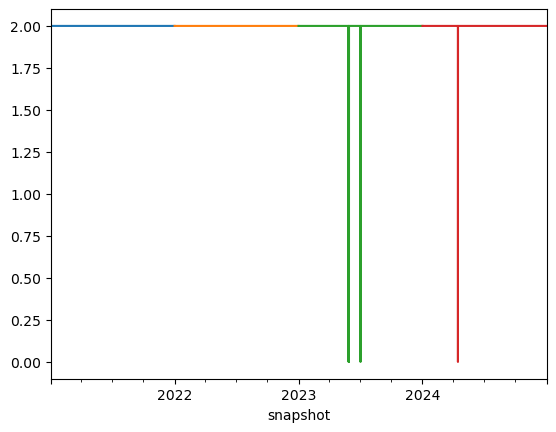

In [402]:
n21.stores_t.p["pellets store"].plot()
n22.stores_t.p["pellets store"].plot()
n23.stores_t.p["pellets store"].plot()
n24.stores_t.p["pellets store"].plot()

In [389]:
"Checking if Heat Load is Matching";
-n21.links_t.p1["NG boiler"] + -n21.links_t.p1["Boiler_Skive"] + -n21.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"] + -n21.links_t.p2["pyrolysis"]

snapshot
2021-01-01 06:00:00    5.05
2021-01-01 07:00:00    5.05
2021-01-01 08:00:00    5.05
2021-01-01 09:00:00    5.05
2021-01-01 10:00:00    5.05
                       ... 
2021-12-31 19:00:00    5.05
2021-12-31 20:00:00    5.05
2021-12-31 21:00:00    5.05
2021-12-31 22:00:00    5.05
2021-12-31 23:00:00    5.05
Freq: h, Length: 8754, dtype: float64

In [447]:
n21.loads

,bus,carrier,type,p_set,q_set,sign,active
Load,,,,,,,
Biogas_Heat,Heat_MT,heat,,5.0,0.0,-1.0,True
Biogas_el,Greenlab,electricity,,2.0,0.0,-1.0,True


In [391]:
n21.statistics()

Optimal Capacity  Installed Capacity  \
Generator   gas                           6.00000                 6.0   
            imports                      84.00000                84.0   
            onshorewind                  54.00000                54.0   
            solar                        30.00000                30.0   
Link        El_Boiler                    10.00000                 0.0   
            NG_boiler                     6.00000                 6.0   
            Pyrolysis                     2.00000                 2.0   
            RONDO_charge                 24.00000                 0.0   
            RONDO_discharge               7.00000                 0.0   
            biochar                       0.90000                 0.0   
            exports                      84.00000                84.0   
            imports                      84.00000                84.0   
Load        electricity                   0.00000                 0.0   
            heat                          0.00000                 0.0   
StorageUnit battery_storage              22.00000                22.0   
Store       RONDO_store                 100.00000                 0.0   
            biochar_sequestered        7878.60000                 0.0   
            exports                  109570.60327                 0.0   
            pellets                  105048.00000            105048.0   

                                       Supply    Withdrawal  Energy Balance  \
Generator   gas                   28811.81105       0.00000     28811.81105   
            imports                1813.65215       0.00000      1813.65215   
            onshorewind          113125.65583       0.00000    113125.65583   
            solar                 30150.30014       0.00000     30150.30014   
Link        El_Boiler                 0.00000    5040.42215     -5040.42215   
            NG_boiler                 0.00000   28811.81105    -28811.81105   
            Pyrolysis                 0.00000   17508.00000    -17508.00000   
            RONDO_charge              0.00000    5709.86992     -5709.86992   
            RONDO_discharge           0.00000    4940.47950     -4940.47950   
            biochar                   0.00000    7878.60000     -7878.60000   
            exports                   0.00000  112959.38482   -112959.38482   
            imports                   0.00000    1813.65215     -1813.65215   
Load        electricity               0.00000   17508.00000    -17508.00000   
            heat                      0.00000   43770.00000    -43770.00000   
StorageUnit battery_storage       21880.63786   25347.99953     -3467.36167   
Store       RONDO_store            4633.01714    5288.21016      -655.19302   
            biochar_sequestered       0.00000    7878.60000     -7878.60000   
            exports                   0.00000  109570.60327   -109570.60327   
            pellets               17508.00000       0.00000     17508.00000   

                                Transmission  Capacity Factor   Curtailment  \
Generator   gas                          0.0         0.548545   23712.18895   
            imports                      0.0         0.002466  733522.34785   
            onshorewind                  0.0         0.239310    1319.35147   
            solar                        0.0         0.114806     398.16586   
Link        El_Boiler                    0.0         0.057579       0.00000   
            NG_boiler                    0.0         0.548545       0.00000   
            Pyrolysis                    0.0         1.000000       0.00000   
            RONDO_charge                 0.0         0.027177       0.00000   
            RONDO_discharge              0.0         0.080624       0.00000   
            biochar                      0.0         1.000000       0.00000   
            exports                      0.0         0.153616       0.00000   
            imports                      0.

## PyPSA HeatMap

In [392]:
def plot_pypsa_heatmap(data, title="PyPSA Heatmap", unit="Value", cmap="viridis", ax=None, vmin=None, vmax=None):
    """
    Added vmin and vmax for manual scale control.
    """
    if isinstance(data, pd.DataFrame):
        plot_data = data.mean(axis=1)
    else:
        plot_data = data

    df = plot_data.to_frame(name="values")
    df["date"] = df.index.date
    df["hour"] = df.index.hour
    
    pivot = df.pivot_table(index="date", columns="hour", values="values", aggfunc='mean')

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    # Pass vmin and vmax here
    sns.heatmap(pivot, cmap=cmap, cbar_kws={'label': unit}, ax=ax, 
                rasterized=True, vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Date")

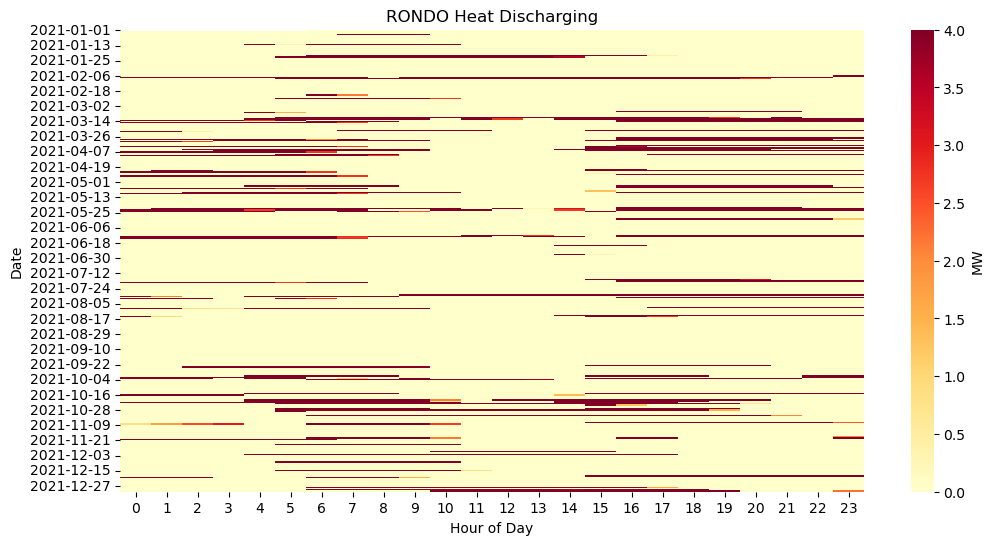

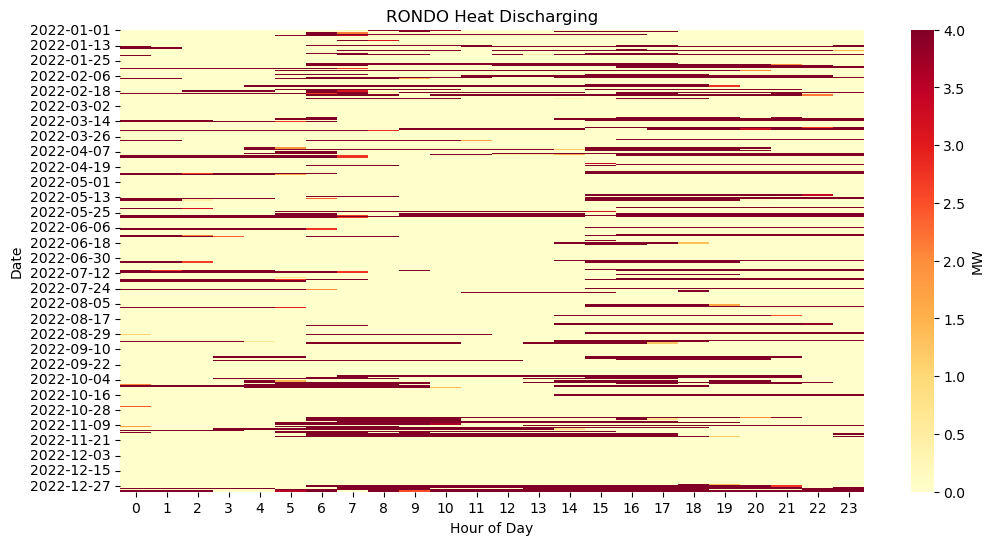

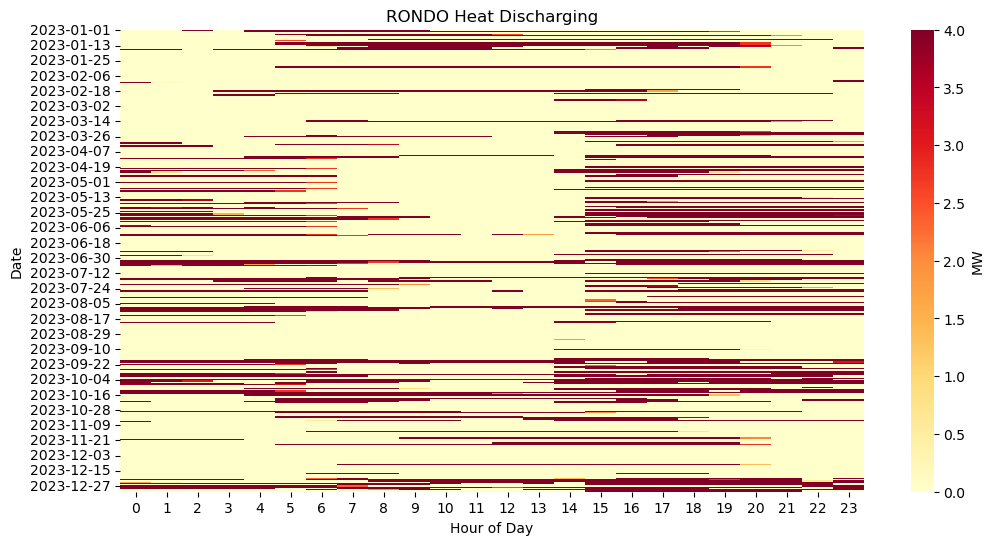

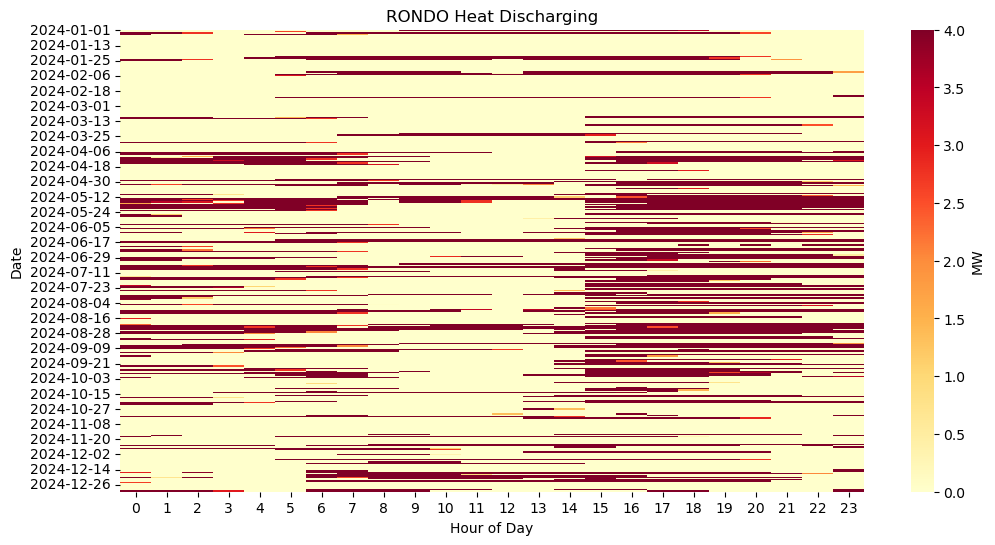

In [403]:

plot_pypsa_heatmap(-n21.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO Heat Discharging", unit="MW", cmap="YlOrRd",vmin= 0, vmax = 4)
plot_pypsa_heatmap(-n22.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO Heat Discharging", unit="MW", cmap="YlOrRd",vmin= 0, vmax = 4)
plot_pypsa_heatmap(-n23.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO Heat Discharging", unit="MW", cmap="YlOrRd",vmin= 0, vmax = 4)
plot_pypsa_heatmap(-n24.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO Heat Discharging", unit="MW", cmap="YlOrRd",vmin= 0, vmax = 4)

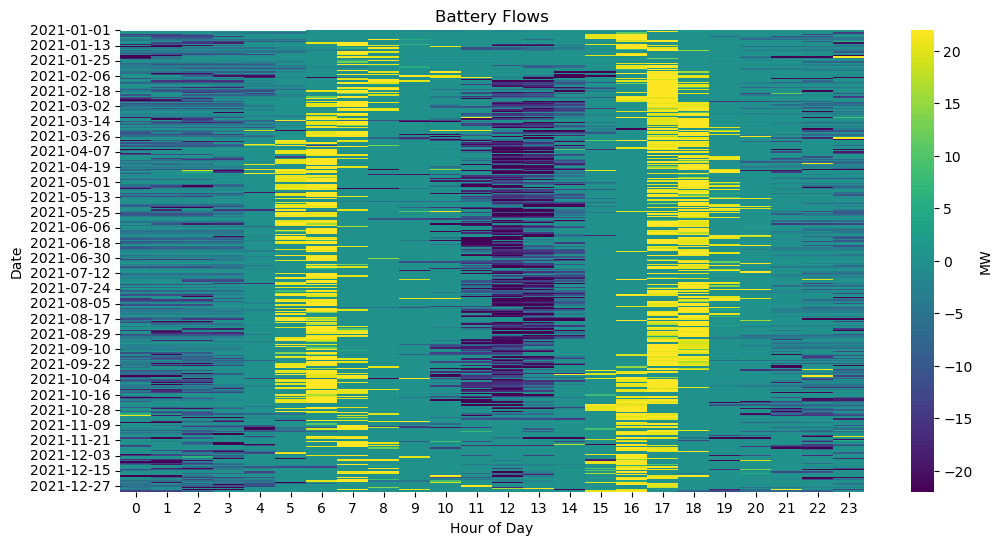

In [116]:
plot_pypsa_heatmap(n21.storage_units_t.p["Skive_Battery"], title="Battery Flows", unit="MW", cmap="viridis", ax=None, vmin=None, vmax=None)

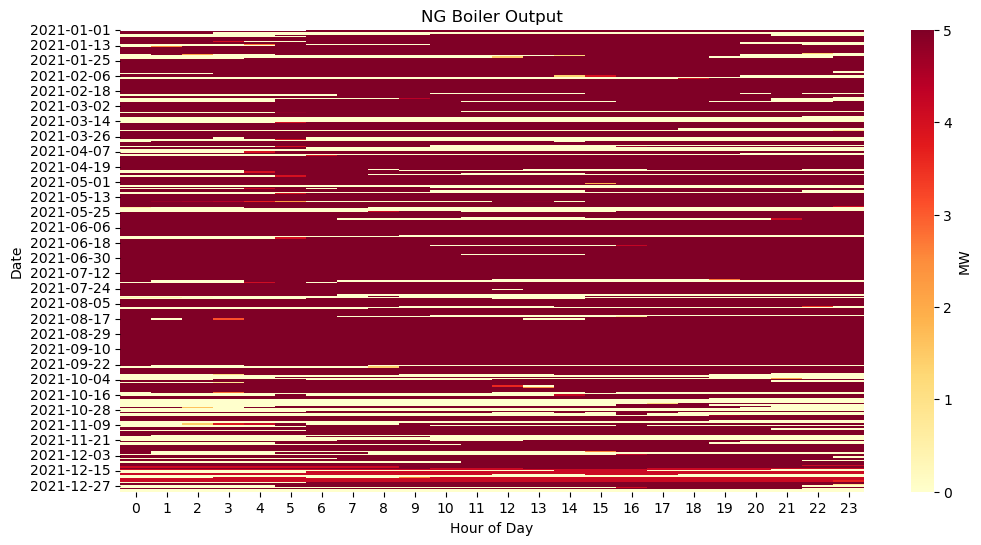

In [148]:
plot_pypsa_heatmap(
-n21.links_t.p1["NG boiler"], title="NG Boiler Output", unit="MW", cmap="YlOrRd", ax=None, vmin=None, vmax=None)

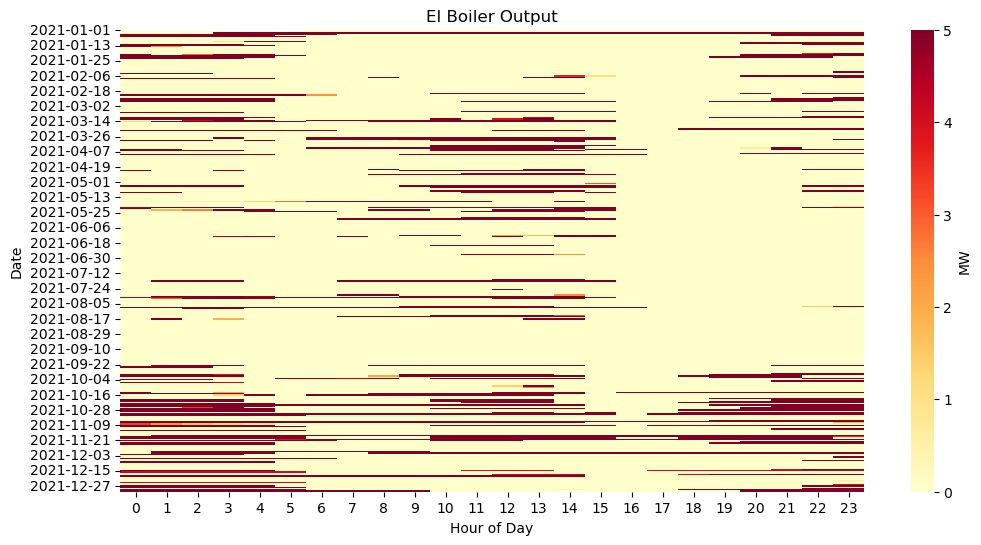

In [150]:
plot_pypsa_heatmap(
-n21.links_t.p1["Boiler_Skive"], title="El Boiler Output", unit="MW", cmap="YlOrRd", ax=None, vmin=None, vmax=None)

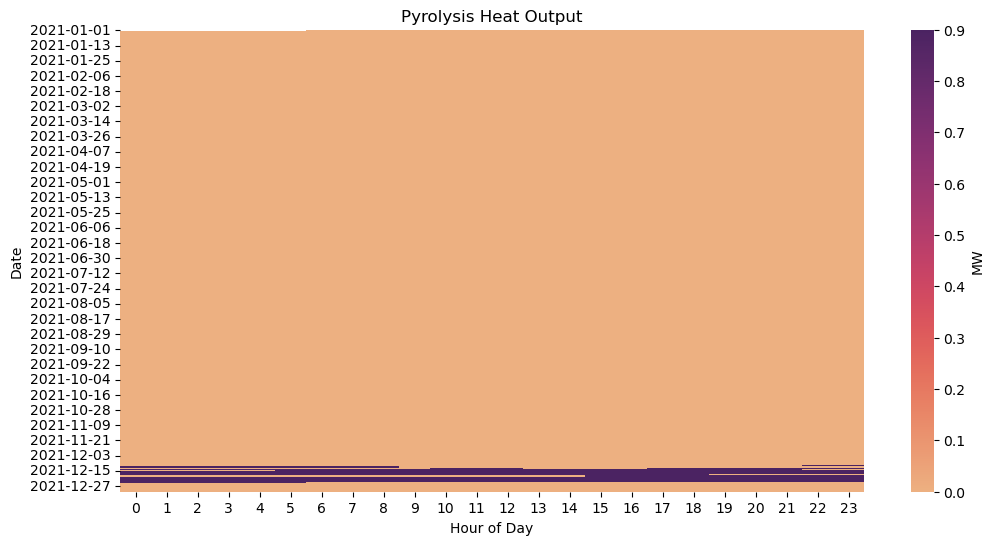

In [155]:
plot_pypsa_heatmap(
-n21.links_t.p2["pyrolysis"], title="Pyrolysis Heat Output", unit="MW", cmap="flare", ax=None, vmin=None, vmax=None)

In [393]:
def plot_heat_summary(n, load_name="Heat_Load_MT", title="Heat Production Mix", 
                      show_stats=True):
    """
    Plots a stacked area chart for your standard Skive/GreenLab heat links.
    """
    # Define your standard links and colors as the 'source of truth'
    standard_links = {
        "Boiler Skive": "Boiler_Skive",
        "NG Boiler": "NG boiler",
        "Pyrolysis": "pyrolysis",
        "RONDO": "TES_Rondo_to_Heat_Bus_Skive"
    }
    colors = ["orange", "blue", "green", "red"]
    
    # 1. Extract and invert the p1 data (converts consumption to production)
    data = {}
    for label, py_name in standard_links.items():
        if py_name in n.links_t.p1.columns:
            data[label] = -n.links_t.p1[py_name]
    
    df = pd.DataFrame(data)

    # 2. Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    df.plot.area(ax=ax, color=colors, alpha=0.8, lw=0)

    # 3. Add the Demand Line
    if load_name in n.loads_t.p_set.columns:
        n.loads_t.p_set[load_name].plot(ax=ax, color="black", lw=1.5, 
                                        ls="--", label="Heat Demand")

    # 4. Formatting
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel("Heat [MW]")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
    plt.tight_layout()
    
    # 5. Print Energy Stats (MWh to GWh)
    if show_stats:
        print(f"\n--- Annual Energy Production (GWh) ---")
        # Sum MW over time and divide by 1000 to get GWh
        stats = df.sum() / 1000 
        print(stats)
        
    return ax


--- Annual Energy Production (GWh) ---
Boiler Skive     4.536380
NG Boiler       28.235575
Pyrolysis        7.440900
RONDO            3.557145
dtype: float64

--- Annual Energy Production (GWh) ---
Boiler Skive     5.263924
NG Boiler       25.933206
Pyrolysis        7.446000
RONDO            5.156870
dtype: float64

--- Annual Energy Production (GWh) ---
Boiler Skive     5.197103
NG Boiler       23.986829
Pyrolysis        7.435800
RONDO            7.180269
dtype: float64

--- Annual Energy Production (GWh) ---
Boiler Skive     7.187959
NG Boiler       20.808003
Pyrolysis        7.464700
RONDO            8.459338
dtype: float64


<Axes: title={'center': 'Heat Production Mix'}, xlabel='snapshot', ylabel='Heat [MW]'>

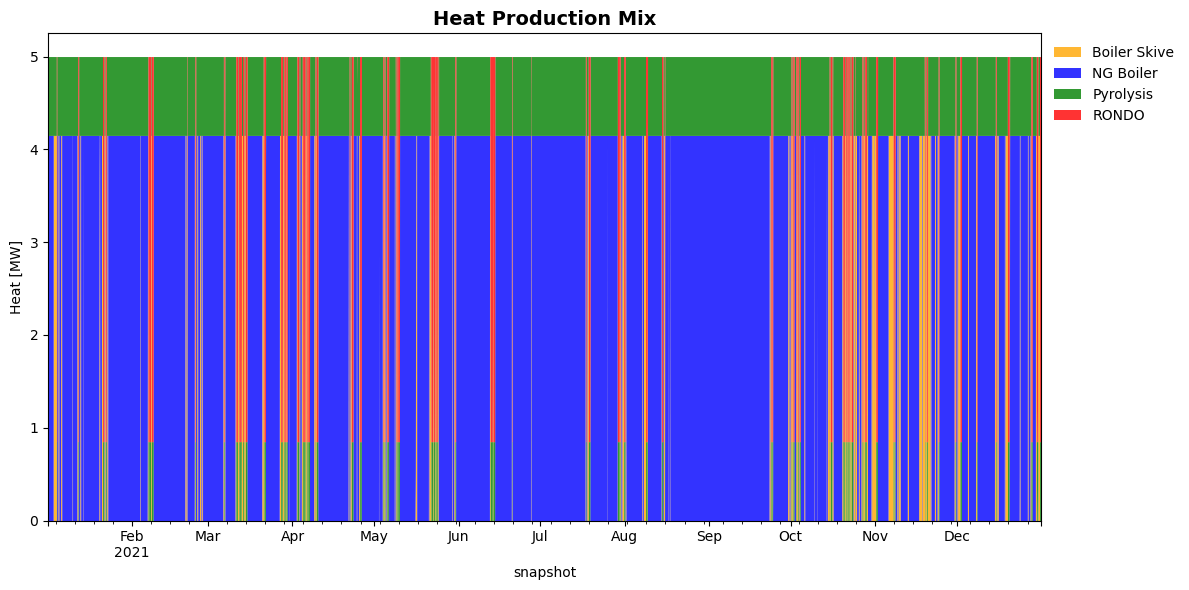

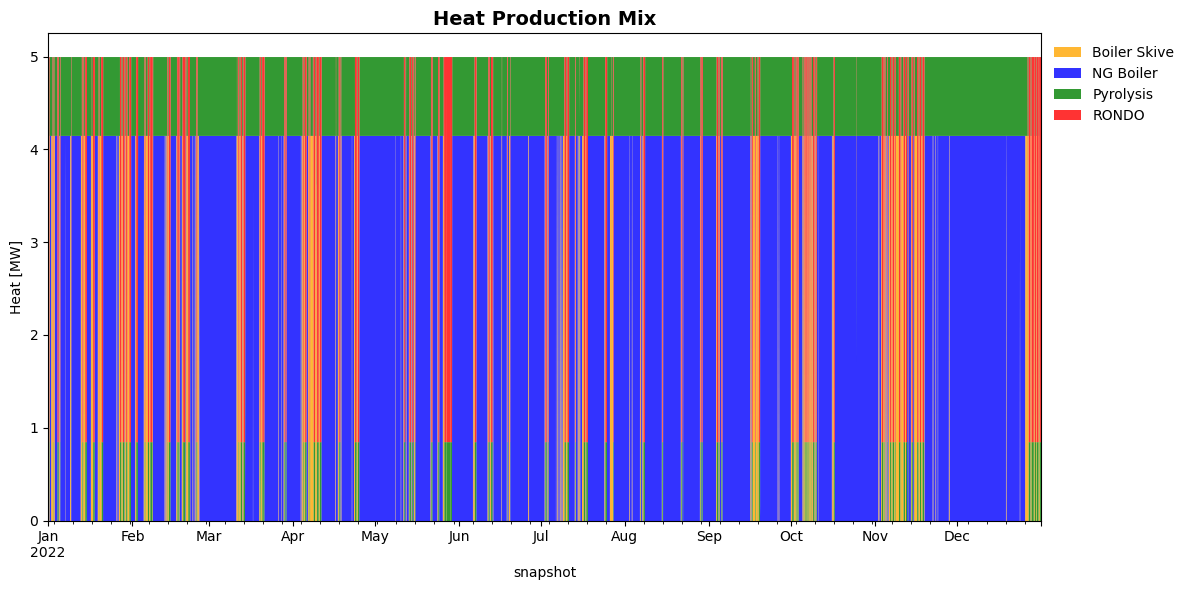

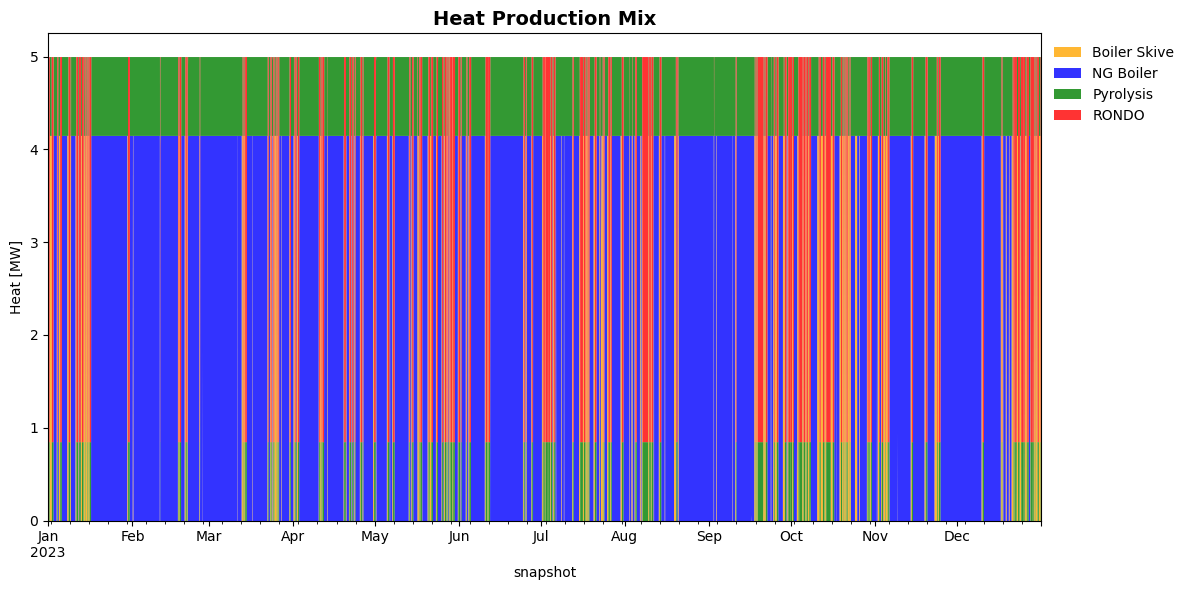

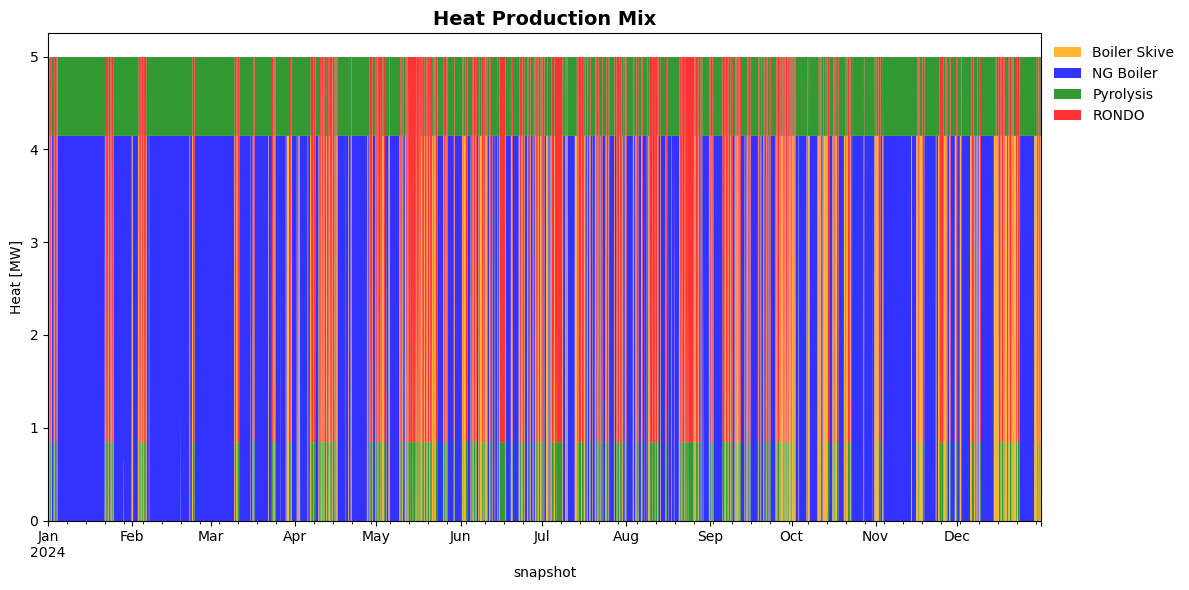

In [394]:
plot_heat_summary(n21, load_name="Heat_Load_MT", title="Heat Production Mix", show_stats=True)
plot_heat_summary(n22, load_name="Heat_Load_MT", title="Heat Production Mix", show_stats=True)
plot_heat_summary(n23, load_name="Heat_Load_MT", title="Heat Production Mix", show_stats=True)
plot_heat_summary(n24, load_name="Heat_Load_MT", title="Heat Production Mix", show_stats=True)

In [395]:
def plot_heat_production(n, title="Annual Heat Production"):
    """
    Plots the annual heat production for RONDO, Electric Boiler, 
    NG Boiler, and Pyrolysis from a PyPSA network.
    """
    # 1. Define the links we are looking for
    target_links = {
        #"RONDO": "Heat_Exchanger_Rondo",
        "RONDO": "TES_Rondo_to_Heat_Bus_Skive",
        "Electric Boiler": "Boiler_Skive",
        "NG Boiler": "NG boiler",
        "Pyrolysis": "pyrolysis"
    }
    
    # 2. Extract values safely (handles missing links with 0.0)
    data = {}
    for label, link_name in target_links.items():
        if link_name in n.links.index:
            # Note: we use .get() or check existence to avoid KeyErrors
            # Summing p1 (output) and converting MW -> GWh
            data[label] = (-n.links_t.p1[link_name].sum()) / 1e3
        else:
            data[label] = 0.0
            
    annual_heat = pd.Series(data)
    total_gwh = annual_heat.sum()
    
    # Avoid division by zero if network is empty/unsolved
    if total_gwh == 0:
        print("Warning: Total heat production is 0. Check if the network is solved.")
        return
    
    # 3. Aesthetics & Sorting
    nice_colors = {'RONDO': '#FFB74D', 'Electric Boiler': '#64B5F6', 
                   'NG Boiler': '#E57373', 'Pyrolysis': '#81C784'}
    
    annual_heat_sorted = annual_heat.sort_values(ascending=False)
    plot_colors = [nice_colors[idx] for idx in annual_heat_sorted.index]
    
    # 4. Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(annual_heat_sorted.index, annual_heat_sorted.values, 
                  color=plot_colors, edgecolor='white', linewidth=1)

    # 5. Data Labels
    for bar in bars:
        height = bar.get_height()
        label_idx = annual_heat_sorted.index[bars.index(bar)]
        pct = (height / total_gwh * 100)
        
        ax.text(bar.get_x() + bar.get_width()/2., height + (total_gwh * 0.01),
                f'{height:.1f} GWh\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Formatting
    ax.set_title(title, fontsize=16, fontweight='bold', pad=25)
    ax.set_ylabel("Total Heat Production [GWh]", fontsize=13)
    ax.set_xlabel("Technology", fontsize=13)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle=':', alpha=0.6)
    
    plt.ylim(0, annual_heat_sorted.max() * 1.2)
    plt.tight_layout()
    plt.show()

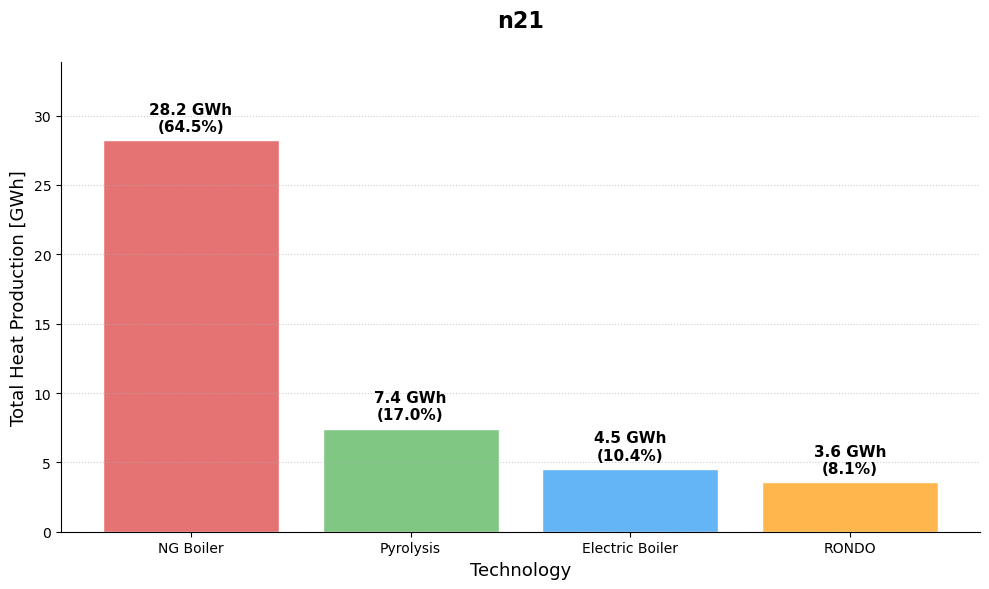

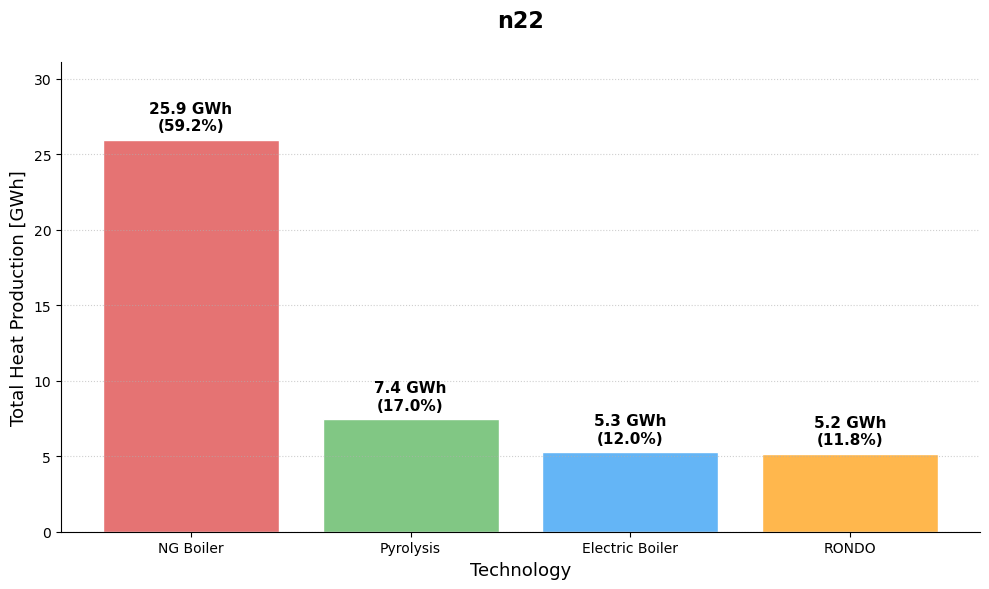

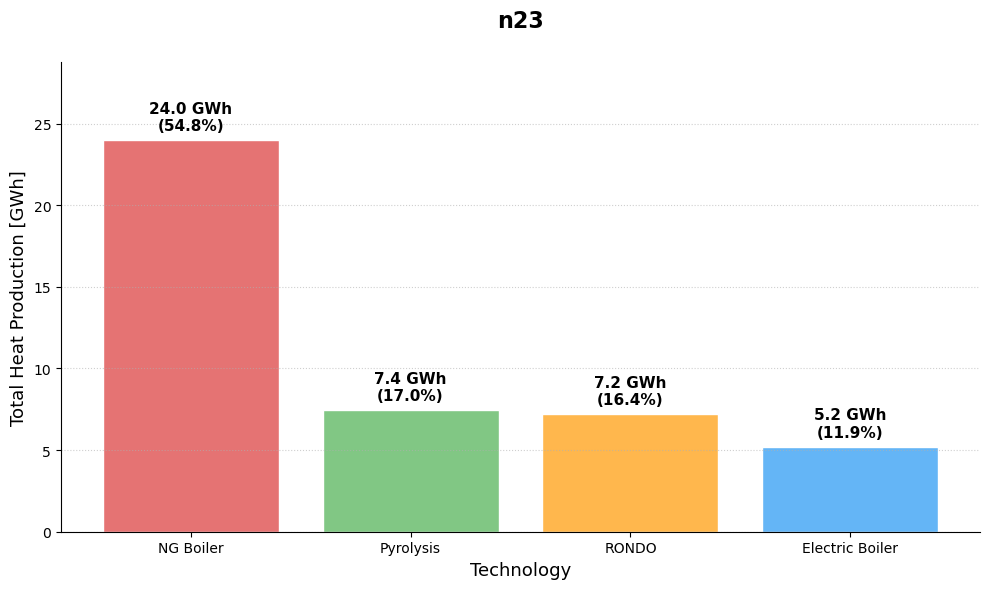

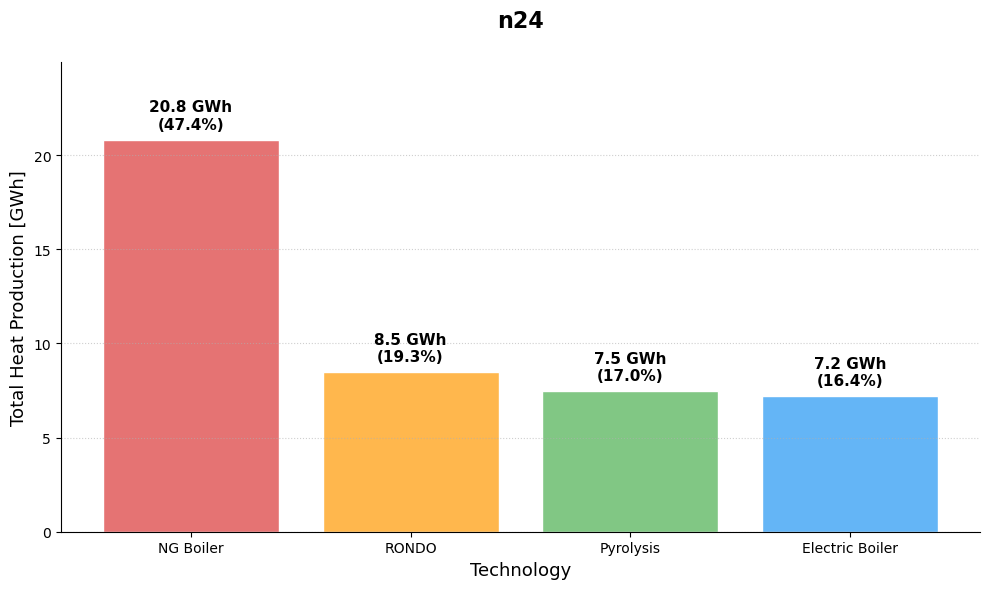

In [396]:
plot_heat_production(n21,title = "n21")
plot_heat_production(n22,title = "n22")
plot_heat_production(n23,title = "n23")
plot_heat_production(n24,title = "n24")

Text(0.5, 1.0, '2 MW Pyrolysis Plant')

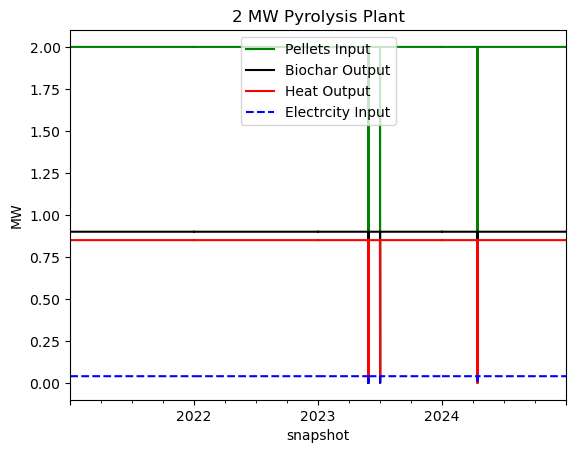

In [404]:
n21.links_t.p0["pyrolysis"].plot(color = "green", label = "Pellets Input")
(-n21.links_t.p2["pyrolysis"]).plot(color = "black", label = "Biochar Output")
(-n21.links_t.p1["pyrolysis"]).plot(color = "red", label = "Heat Output")
n21.links_t.p3["pyrolysis"].plot(color = "blue", label = "Electrcity Input",linestyle = "--")
plt.ylabel("MW")
plt.legend()

n22.links_t.p0["pyrolysis"].plot(color = "green", label = "Pellets Input")
(-n22.links_t.p2["pyrolysis"]).plot(color = "black", label = "Biochar Output")
(-n22.links_t.p1["pyrolysis"]).plot(color = "red", label = "Heat Output")
n22.links_t.p3["pyrolysis"].plot(color = "blue", label = "Electrcity Input",linestyle = "--")

n23.links_t.p0["pyrolysis"].plot(color = "green", label = "Pellets Input")
(-n23.links_t.p2["pyrolysis"]).plot(color = "black", label = "Biochar Output")
(-n23.links_t.p1["pyrolysis"]).plot(color = "red", label = "Heat Output")
n23.links_t.p3["pyrolysis"].plot(color = "blue", label = "Electrcity Input",linestyle = "--")

n24.links_t.p0["pyrolysis"].plot(color = "green", label = "Pellets Input")
(-n24.links_t.p2["pyrolysis"]).plot(color = "black", label = "Biochar Output")
(-n24.links_t.p1["pyrolysis"]).plot(color = "red", label = "Heat Output")
n24.links_t.p3["pyrolysis"].plot(color = "blue", label = "Electrcity Input",linestyle = "--")

plt.title("2 MW Pyrolysis Plant")

In [405]:
n21.buses_t.marginal_price

Bus,Greenlab,Grid_Import,Grid_Export,Heat_MT,TES_Rondo,pellets,biochar,biochar sequestration,NG
snapshot,,,,,,,,,
2021-01-01 06:00:00,47.726105,0.0,0.0,35.761423,46.404244,0.0,25.04,0.0,35.046195
2021-01-01 07:00:00,47.726105,0.0,0.0,35.761423,46.967858,0.0,25.04,0.0,35.046195
2021-01-01 08:00:00,47.726105,0.0,0.0,35.761423,47.538318,0.0,25.04,0.0,35.046195
2021-01-01 09:00:00,47.726105,0.0,0.0,35.761423,48.115706,0.0,25.04,0.0,35.046195
2021-01-01 10:00:00,47.726105,0.0,0.0,35.761423,48.700108,0.0,25.04,0.0,35.046195
...,...,...,...,...,...,...,...,...,...
2021-12-31 19:00:00,47.726105,0.0,0.0,52.688876,37.935991,0.0,25.04,0.0,85.229640
2021-12-31 20:00:00,47.726105,0.0,0.0,53.029006,38.396752,0.0,25.04,0.0,85.229640
2021-12-31 21:00:00,47.726105,0.0,0.0,53.029006,38.863109,0.0,25.04,0.0,85.229640


<Axes: xlabel='snapshot'>

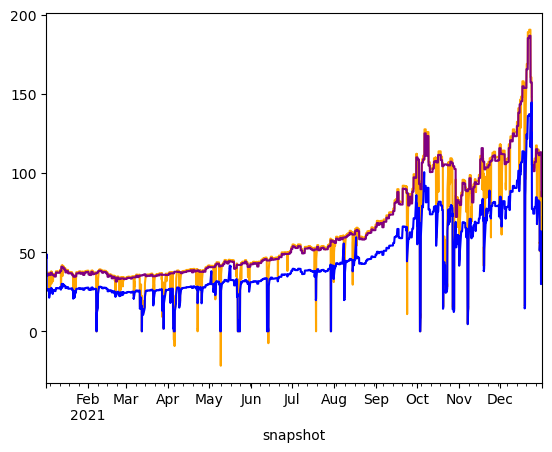

In [406]:
n21.buses_t.marginal_price["Heat_MT"].plot(color ="Orange")
n21.buses_t.marginal_price["NG"].plot(color ="purple")
n21.buses_t.marginal_price["TES_Rondo"].plot(color ="blue")

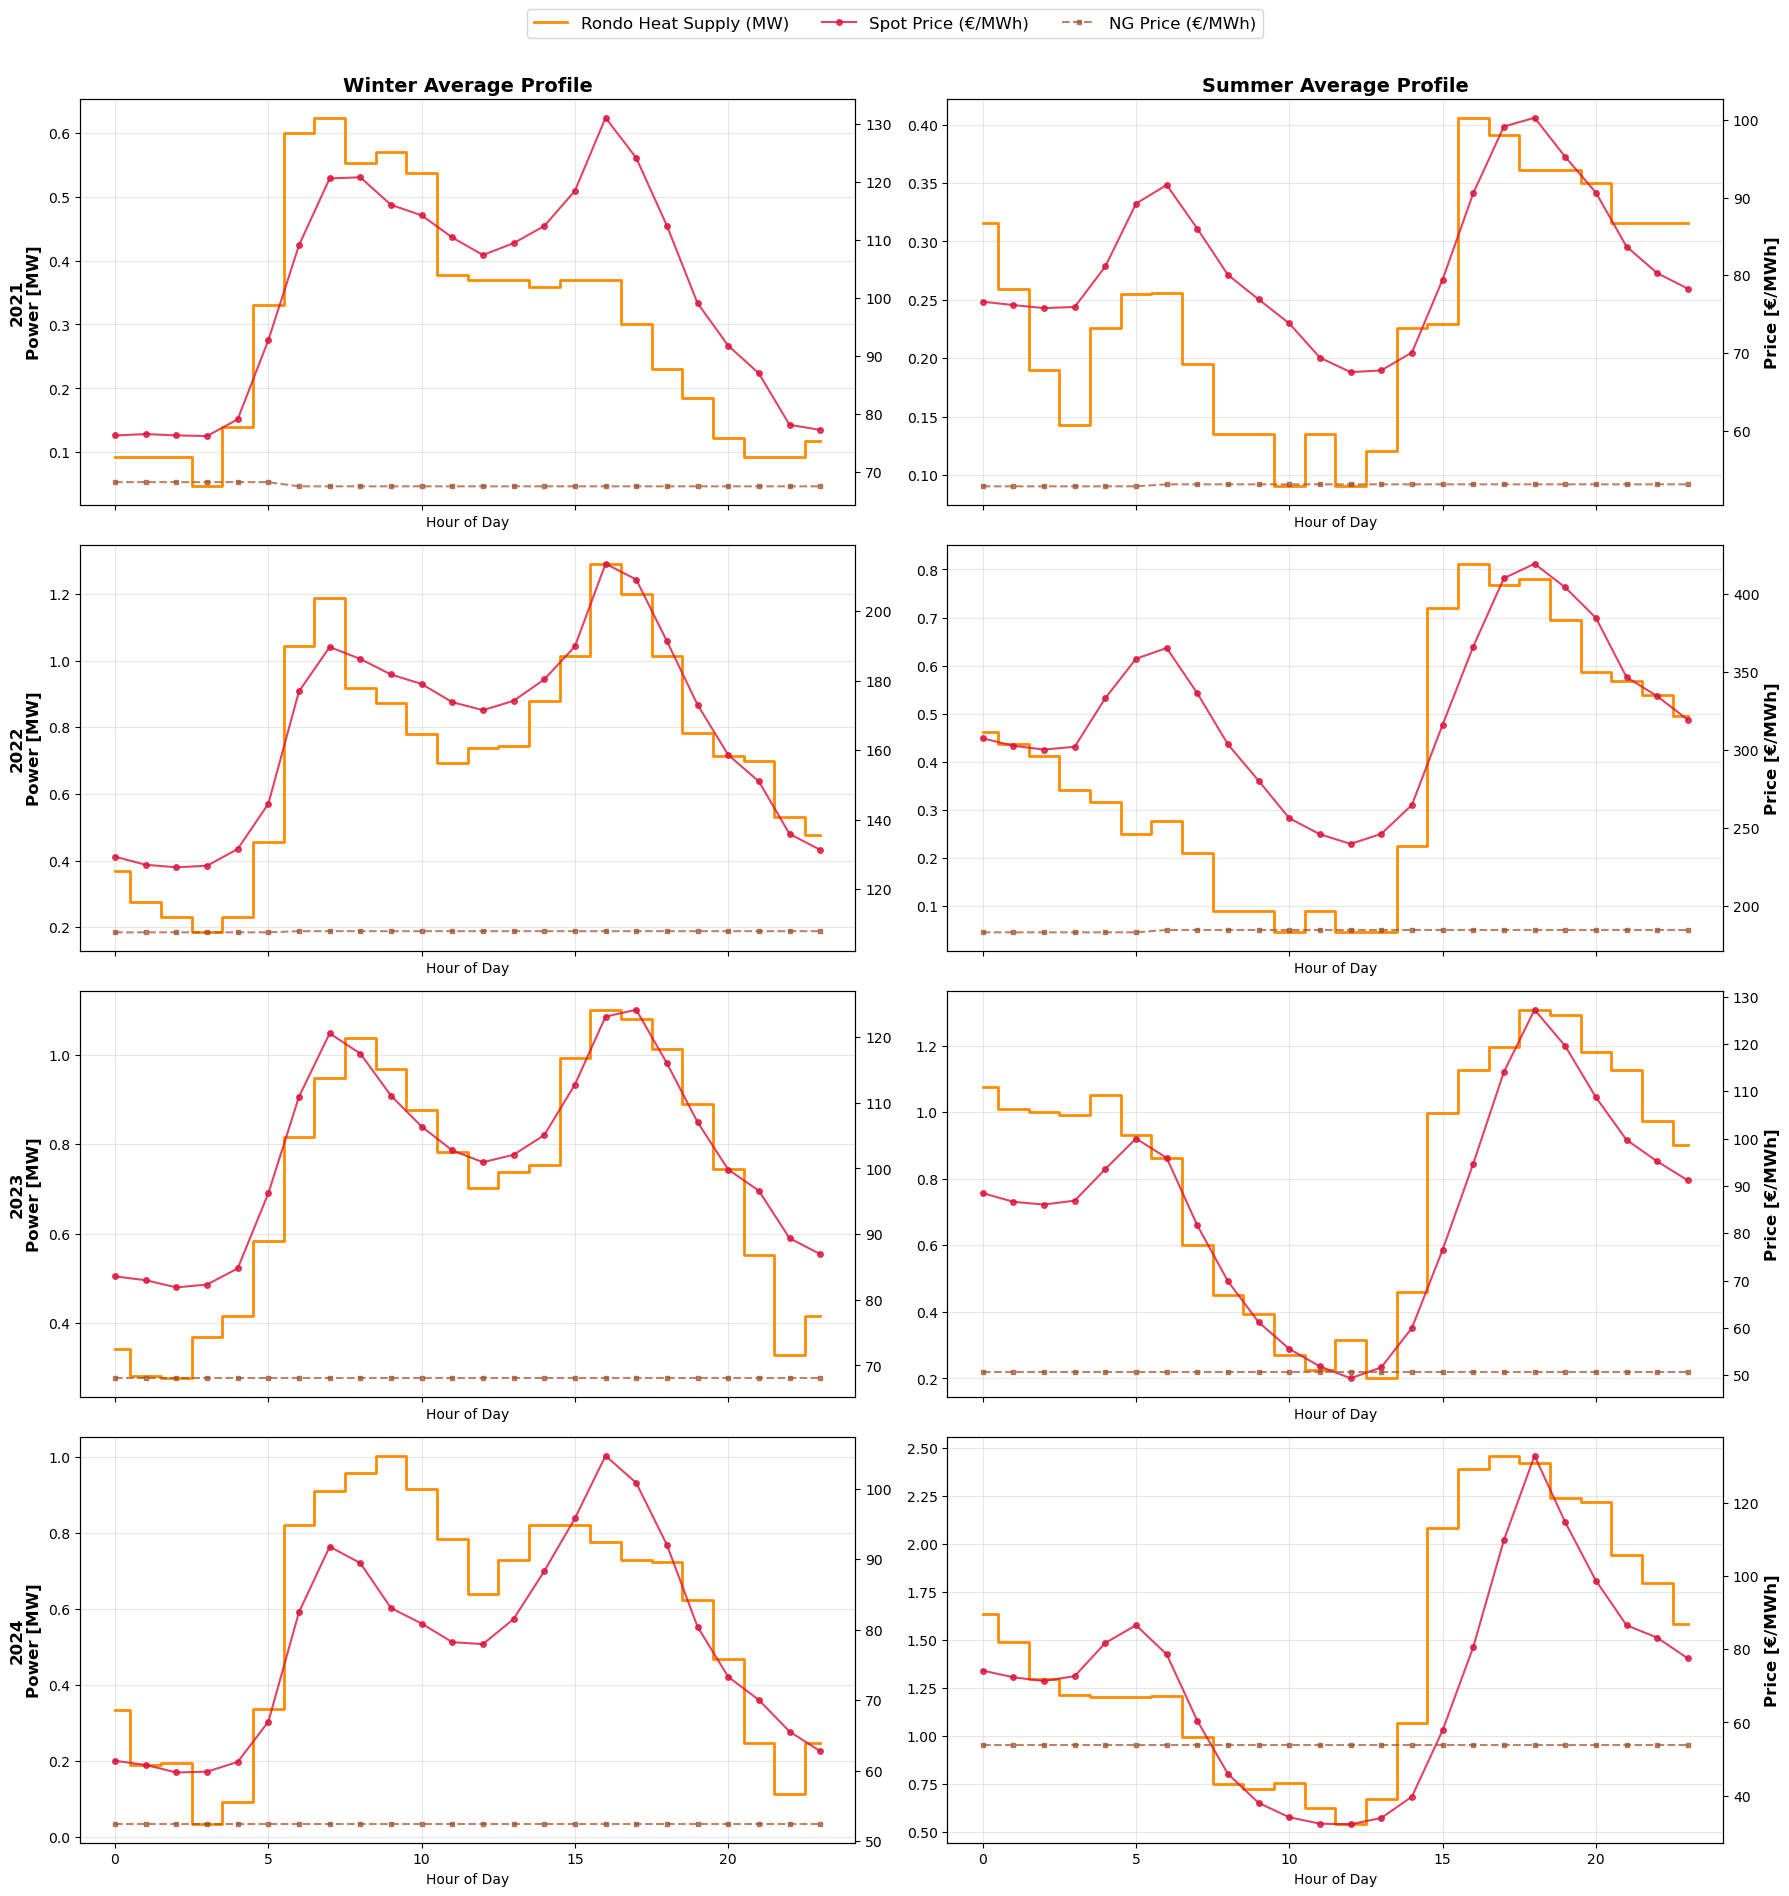

In [407]:
def plot_seasonal_profiles(networks, year_labels):
    # ADDED squeeze=False HERE to prevent the IndexError
    fig, axes = plt.subplots(len(networks), 2, figsize=(18, 5 * len(networks)), sharex=True, squeeze=False)
    
    for i, (label, n) in enumerate(zip(year_labels, networks)):
        # 1. Extract and Prep Data
        # Fixed the missing comma and added NG Price extraction
        df = pd.DataFrame({
            'Price': n.buses_t.marginal_price["Greenlab"],
            'NG Price': n.buses_t.marginal_price["NG"], 
            'Battery': n.storage_units_t.p["Skive_Battery"],
            'Rondo_Heat': -n.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"]
        })
        df['hour'] = df.index.hour
        df['month'] = df.index.month

        # 2. Filter Seasons
        winter = df[df['month'].isin([12, 1, 2])].groupby('hour').mean()
        summer = df[df['month'].isin([6, 7, 8])].groupby('hour').mean()

        for j, (data, season) in enumerate(zip([winter, summer], ["Winter", "Summer"])):
            ax = axes[i, j] 
            ax2 = ax.twinx() 

            # Plot Rondo (Step) - Primary Axis
            ln2 = ax.step(data.index, data['Rondo_Heat'], color='darkorange', label='Rondo Heat Supply (MW)', where='mid', lw=2)
            
            # Plot Electricity Price (Solid Line) - Secondary Axis
            ln3 = ax2.plot(data.index, data['Price'], color='crimson', label='Spot Price (€/MWh)', marker='o', markersize=4, alpha=0.8)
            
            # NEW: Plot NG Price (Dashed Line) - Secondary Axis
            # Using 'sienna' or 'brown' to represent gas/earth tones
            ln4 = ax2.plot(data.index, data['NG Price'], color='sienna', label='NG Price (€/MWh)', linestyle='--', marker='s', markersize=3, alpha=0.7)

            # Labels and Titles
            if i == 0: ax.set_title(f"{season} Average Profile", fontsize=14, fontweight='bold')
            if j == 0: ax.set_ylabel(f"{label}\nPower [MW]", fontsize=12, fontweight='bold')
            if j == 1: ax2.set_ylabel("Price [€/MWh]", fontsize=12, fontweight='bold', color='black')
            
            ax.set_xlabel("Hour of Day")
            ax.grid(True, alpha=0.3)
            
            # 3. Create Unified Legend (Only on the first plot to save space)
            if i == 0 and j == 0:
                # Combined lines from both axes for the legend
                lines = [ln2[0], ln3[0], ln4[0]]
                labels = [l.get_label() for l in lines]
                fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run for your weather years
plot_seasonal_profiles([n21, n22, n23, n24], ["2021", "2022", "2023", "2024"])


<Axes: title={'center': 'Energy Supply Breakdown for 2021'}, xlabel='component,carrier', ylabel='Energy Supply [GWh]'>

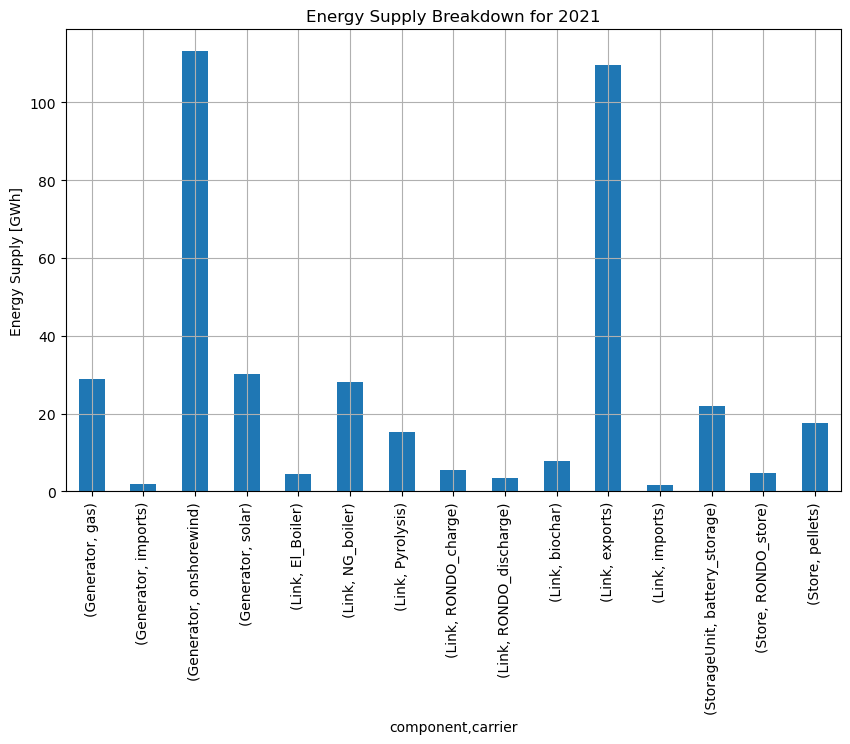

In [408]:
# Convert to MWh (or appropriate unit) and plot as a bar chart
# Note: n.statistics.supply() typically returns energy in MWh if p is in MW
(n21.statistics.supply()/1e3).plot.bar(
    ylabel="Energy Supply [GWh]",
    title="Energy Supply Breakdown for 2021",
    figsize=(10, 6),
    grid=True
)

<Axes: title={'center': 'Energy Supply Breakdown for 2021'}, xlabel='component,carrier', ylabel='Energy Supply [GWh]'>

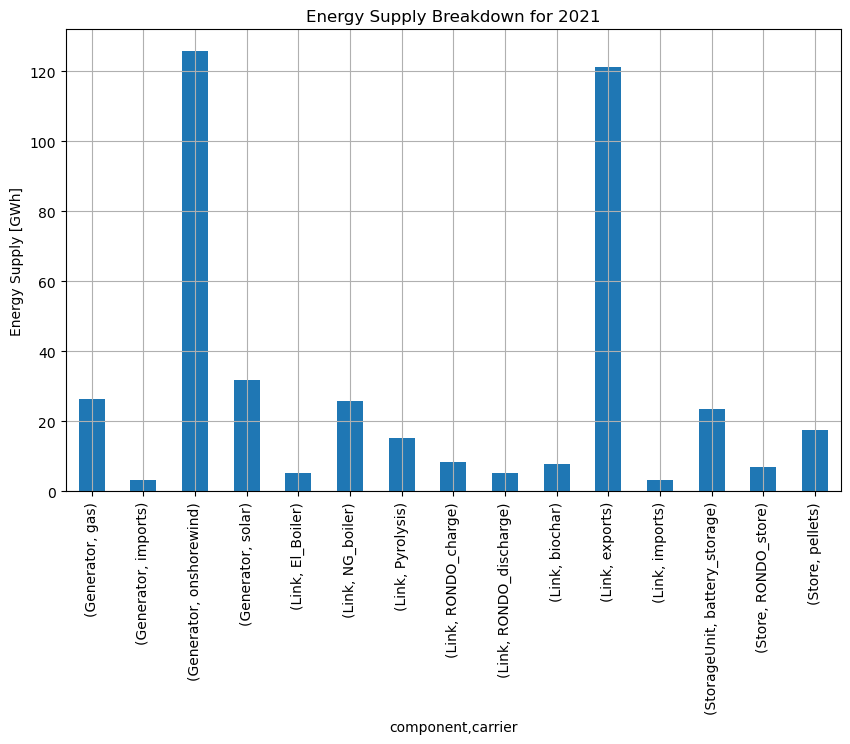

In [409]:
(n22.statistics.supply()/1e3).plot.bar(
    ylabel="Energy Supply [GWh]",
    title="Energy Supply Breakdown for 2021",
    figsize=(10, 6),
    grid=True
)

<Axes: title={'center': 'OPEX'}, ylabel='Cost [MEUR]'>

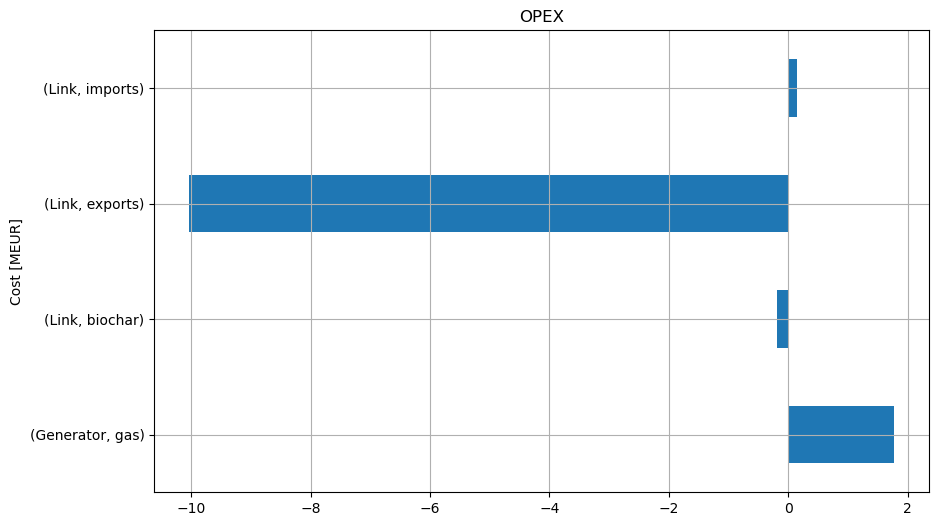

In [434]:
(n21.statistics.opex()/1e6).plot.barh(
    ylabel="Cost [MEUR]",
    title="OPEX",
    figsize=(10, 6),
    grid=True
)

<Axes: title={'center': 'OPEX'}, ylabel='Cost [MEUR]'>

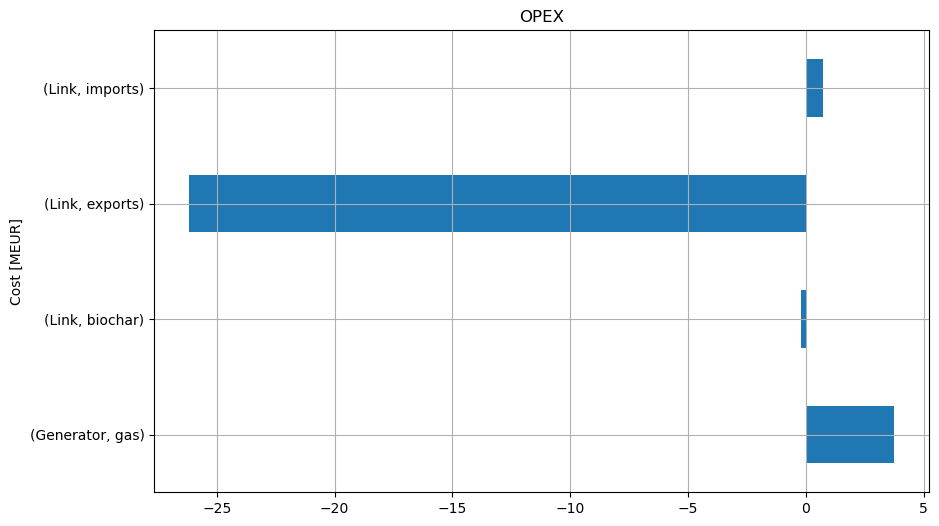

In [435]:
(n22.statistics.opex()/1e6).plot.barh(
    ylabel="Cost [MEUR]",
    title="OPEX",
    figsize=(10, 6),
    grid=True
)

<Axes: title={'center': 'OPEX'}, ylabel='Cost [MEUR]'>

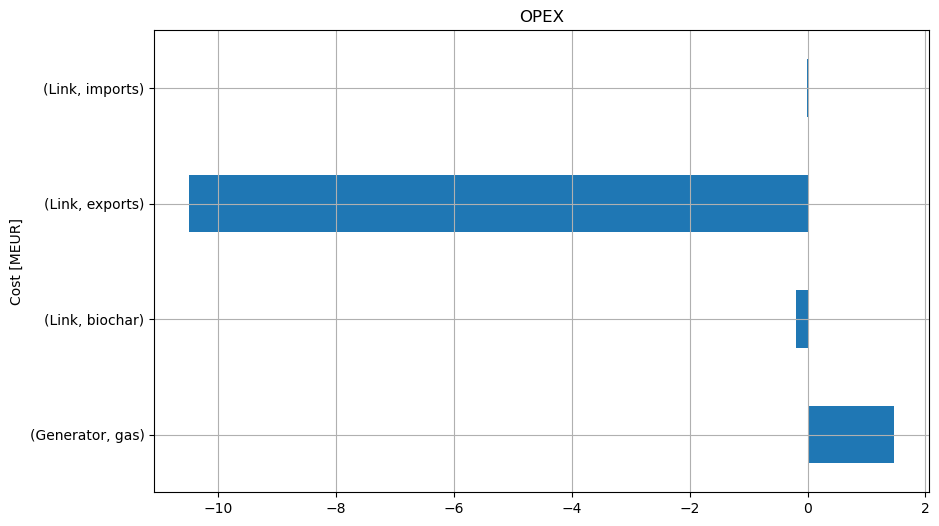

In [436]:
(n23.statistics.opex()/1e6).plot.barh(
    ylabel="Cost [MEUR]",
    title="OPEX",
    figsize=(10, 6),
    grid=True
)

<Axes: title={'center': 'OPEX'}, ylabel='Cost [MEUR]'>

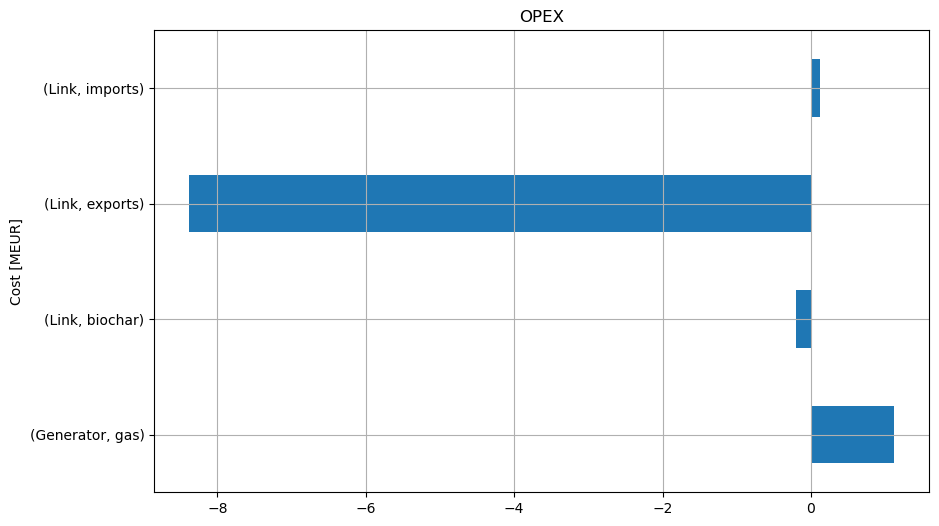

In [437]:
(n24.statistics.opex()/1e6).plot.barh(
    ylabel="Cost [MEUR]",
    title="OPEX",
    figsize=(10, 6),
    grid=True
)

<Axes: xlabel='snapshot'>

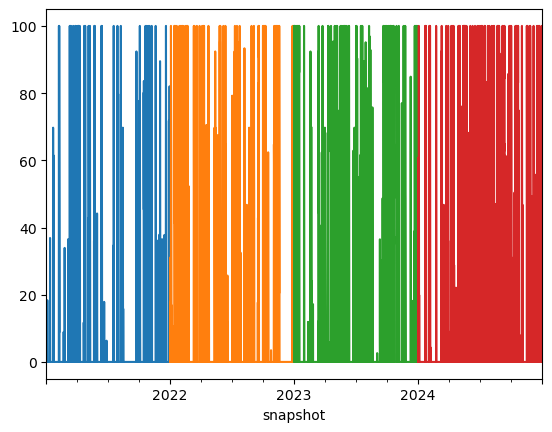

In [428]:
n21.stores_t.e["Rondo_Concrete_Heat_Storage"].plot()
n22.stores_t.e["Rondo_Concrete_Heat_Storage"].plot()
n23.stores_t.e["Rondo_Concrete_Heat_Storage"].plot()
n24.stores_t.e["Rondo_Concrete_Heat_Storage"].plot()

In [433]:
[n21.statistics.opex().sum()/1e6, n22.statistics.opex().sum()/1e6, n23.statistics.opex().sum()/1e6, n24.statistics.opex().sum()/1e6]

[-8.31393456958, -21.875267459630003, -9.227738099580002, -7.33226324614]

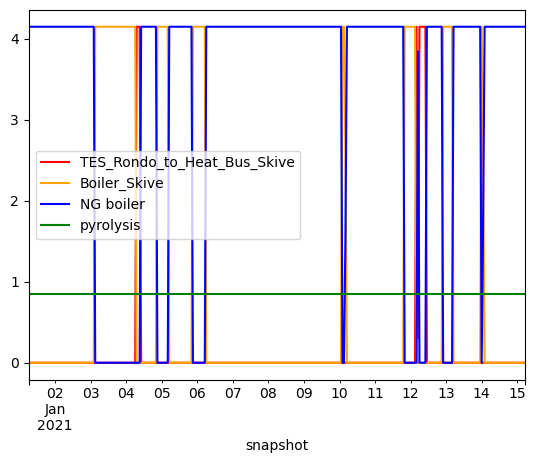

In [440]:
(-n21.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"][0:24*7*2]).plot(color = "red")
(-n21.links_t.p1["Boiler_Skive"][0:24*7*2]).plot(color = "orange")
(-n21.links_t.p1["NG boiler"][0:24*7*2]).plot(color = "blue")
(-n21.links_t.p1["pyrolysis"][0:24*7*2]).plot(color = "green")
plt.legend()

### Rolling Horizon Case 1

In [448]:
def prepare_rolling_horizon(n_input):
    """
    Takes a solved Perfect Foresight network, copies it, freezes 
    optimized capacities, and prepares it for Rolling Horizon.
    """
    # 1. Clean up and Copy
    if hasattr(n_input, 'model'):
        del n_input.model
    
    n_rh = n_input.copy()
    
    # 2. Fix Links (Biogas, Boilers, Grid Links)
    if not n_rh.links.empty:
        n_rh.links.p_nom = n_rh.links.p_nom_opt
        n_rh.links.p_nom_extendable = False
        
    # 3. Fix Generators (Wind, Solar)
    if not n_rh.generators.empty:
        n_rh.generators.p_nom = n_rh.generators.p_nom_opt
        n_rh.generators.p_nom_extendable = False
        
    # 4. Fix Storage Units (Batteries)
    if not n_rh.storage_units.empty:
        n_rh.storage_units.p_nom = n_rh.storage_units.p_nom_opt
        n_rh.storage_units.p_nom_extendable = False
        
    # 5. Fix Stores (Biomass, H2, Methane, TES Rondo)
    if not n_rh.stores.empty:
        n_rh.stores.e_nom = n_rh.stores.e_nom_opt
        n_rh.stores.e_nom_extendable = False
        
    print("✅ Capacities fixed. Network ready for Rolling Horizon.")
    return n_rh

In [449]:
n21.buses_t.marginal_price

Bus,Greenlab,Grid_Import,Grid_Export,Heat_MT,TES_Rondo,pellets,biochar,biochar sequestration,NG
snapshot,,,,,,,,,
2021-01-01 06:00:00,47.726105,0.0,0.0,35.761423,46.404244,0.0,25.04,0.0,35.046195
2021-01-01 07:00:00,47.726105,0.0,0.0,35.761423,46.967858,0.0,25.04,0.0,35.046195
2021-01-01 08:00:00,47.726105,0.0,0.0,35.761423,47.538318,0.0,25.04,0.0,35.046195
2021-01-01 09:00:00,47.726105,0.0,0.0,35.761423,48.115706,0.0,25.04,0.0,35.046195
2021-01-01 10:00:00,47.726105,0.0,0.0,35.761423,48.700108,0.0,25.04,0.0,35.046195
...,...,...,...,...,...,...,...,...,...
2021-12-31 19:00:00,47.726105,0.0,0.0,52.688876,37.935991,0.0,25.04,0.0,85.229640
2021-12-31 20:00:00,47.726105,0.0,0.0,53.029006,38.396752,0.0,25.04,0.0,85.229640
2021-12-31 21:00:00,47.726105,0.0,0.0,53.029006,38.863109,0.0,25.04,0.0,85.229640


In [451]:
n21.links_t.marginal_cost

Link,Exports,Imports
snapshot,,
2021-01-01 06:00:00,-39.806107,76.565213
2021-01-01 07:00:00,-40.986107,78.151879
2021-01-01 08:00:00,-44.596108,82.048547
2021-01-01 09:00:00,-44.716107,82.688546
2021-01-01 10:00:00,-46.916108,84.795214
...,...,...
2021-12-31 19:00:00,-33.676106,67.196464
2021-12-31 20:00:00,-32.796109,66.196467
2021-12-31 21:00:00,-32.056107,60.841879
